# EDA de Calidad del Aire Histórico

## TFM Smart Air Spain

Este notebook presenta el análisis exploratorio y la auditoría de calidad del conjunto de datos histórico de calidad del aire correspondiente al periodo 2020-2024.

El objetivo es evaluar la integridad, consistencia y comportamiento de las mediciones antes de realizar la agregación diaria, la integración con los datos meteorológicos de AEMET y la construcción de modelos predictivos.

### Contenido

1. Carga y estructura del conjunto de datos  
2. Validaciones de integridad  
3. Calidad y cobertura de los datos  
4. Estadística descriptiva por contaminante  
5. Detección y análisis de valores atípicos  
6. Evolución temporal y estacionalidad  
7. Comparación entre estaciones  
8. Relación entre contaminantes  
9. Agregación diaria  
10. Conclusiones y decisiones de preprocesado  

# Carga del entorno y configuración

Antes de comenzar el análisis se cargan las librerías necesarias y se configuran las rutas del proyecto.

Para facilitar la portabilidad del notebook, las rutas se construyen de forma dinámica a partir del directorio de trabajo, evitando el uso de rutas absolutas. De este modo, el notebook puede ejecutarse en cualquier equipo siempre que se mantenga la estructura del proyecto.

Asimismo, el conjunto de datos principal se cargará mediante **Polars** utilizando lectura *lazy* (`scan_parquet()`), lo que permite trabajar de forma eficiente con un volumen superior a cien millones de registros sin necesidad de cargar el archivo completo en memoria.

In [1]:
from pathlib import Path

import polars as pl
import matplotlib.pyplot as plt

pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_cols(20)


PROJECT_ROOT = Path.cwd().parents[2]

AIR_FILE = (
    PROJECT_ROOT
    / "data"
    / "normalized"
    / "fact"
    / "calidad_aire_historico.parquet"
)

SEED_FILE = (
    PROJECT_ROOT
    / "data"
    / "normalized"
    / "static_files"
    / "seed_variable_aire.parquet"
)

print(f"Directorio actual: {Path.cwd()}")
print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Dataset de aire: {AIR_FILE}")
print(f"Existe el archivo: {AIR_FILE.exists()}")
print(f"Existe el seed: {SEED_FILE.exists()}")

Directorio actual: c:\Users\borja\Desktop\Master\TFM\src\eda\Notebooks
Raíz del proyecto: c:\Users\borja\Desktop\Master\TFM
Dataset de aire: c:\Users\borja\Desktop\Master\TFM\data\normalized\fact\calidad_aire_historico.parquet
Existe el archivo: True
Existe el seed: True


In [2]:
aire = pl.scan_parquet(AIR_FILE)
seed_aire = pl.read_parquet(SEED_FILE)

print("Dataset de aire cargado en modo lazy.")
print(aire.collect_schema())

print("\nTabla de metadatos:")
print(seed_aire.head())

Dataset de aire cargado en modo lazy.
Schema({'provincia': Int64, 'municipio': Int64, 'estacion': Int64, 'magnitud': Int64, 'punto_muestreo': String, 'fecha': Datetime(time_unit='us', time_zone=None), 'uom': String, 'uom_value': Float64})

Tabla de metadatos:
shape: (5, 5)
┌──────────┬────────────────────────────┬─────────────┬────────┬───────────────────────────────────┐
│ MAGNITUD ┆ NOMBRE                     ┆ ABREVIATURA ┆ UNIDAD ┆ GRUPO                             │
│ ---      ┆ ---                        ┆ ---         ┆ ---    ┆ ---                               │
│ i64      ┆ str                        ┆ str         ┆ str    ┆ str                               │
╞══════════╪════════════════════════════╪═════════════╪════════╪═══════════════════════════════════╡
│ 1        ┆ DIÓXIDO DE AZUFRE          ┆ SO2         ┆ µg/m3  ┆ Contaminantes con valor legisl…   │
│ 6        ┆ MONÓXIDO DE CARBONO        ┆ CO          ┆ mg/m3  ┆ Contaminantes con valor legisl…   │
│ 7        ┆ MONÓXI

## 1. Carga, estructura y validaciones de integridad

En esta sección se realiza una primera revisión del conjunto de datos normalizado de calidad del aire.

El objetivo es comprobar su estructura general, el periodo temporal cubierto, el número de localizaciones y magnitudes disponibles, así como verificar que los tipos de datos son adecuados para el análisis posterior.

Debido al elevado tamaño del conjunto de datos, la lectura se realiza en modo *lazy* mediante Polars, ejecutando únicamente las consultas necesarias.

In [3]:
# Resumen general del dataset

resumen = (
    aire.select(
        pl.len().alias("n_filas"),
        pl.col("fecha").min().alias("fecha_min"),
        pl.col("fecha").max().alias("fecha_max"),
        pl.col("provincia").n_unique().alias("n_provincias"),
        pl.col("municipio").n_unique().alias("n_municipios"),
        pl.col("estacion").n_unique().alias("n_estaciones"),
        pl.col("magnitud").n_unique().alias("n_magnitudes"),
        pl.col("punto_muestreo").n_unique().alias("n_puntos_muestreo"),
        pl.col("uom").n_unique().alias("n_unidades")
    )
    .collect()
    .to_dicts()[0]
)

print("=" * 70)
print("RESUMEN GENERAL DEL DATASET")
print("=" * 70)

print(f"📄 Número de registros : {resumen['n_filas']:,}")
print(f"📅 Periodo temporal    : {resumen['fecha_min']} → {resumen['fecha_max']}")
print(f"🗺️  Provincias         : {resumen['n_provincias']}")
print(f"🏙️  Municipios         : {resumen['n_municipios']}")
print(f"📍 Estaciones          : {resumen['n_estaciones']}")
print(f"🌫️  Magnitudes         : {resumen['n_magnitudes']}")
print(f"📡 Puntos de muestreo  : {resumen['n_puntos_muestreo']:,}")
print(f"📏 Unidades distintas  : {resumen['n_unidades']}")

RESUMEN GENERAL DEL DATASET
📄 Número de registros : 109,384,590
📅 Periodo temporal    : 2020-01-01 00:00:00 → 2024-12-31 23:00:00
🗺️  Provincias         : 52
🏙️  Municipios         : 178
📍 Estaciones          : 60
🌫️  Magnitudes         : 21
📡 Puntos de muestreo  : 3,801
📏 Unidades distintas  : 4


### Interpretación

El conjunto de datos contiene **109.384.590 registros horarios** correspondientes a mediciones de calidad del aire realizadas entre el **1 de enero de 2020** y el **31 de diciembre de 2024**.

Las observaciones proceden de **60 estaciones de medida**, distribuidas en **178 municipios** pertenecientes a las **52 provincias españolas**. En total se registran **21 magnitudes**, correspondientes a distintos contaminantes atmosféricos, identificadas mediante **3.801 puntos de muestreo**.

Asimismo, el conjunto de datos utiliza **cuatro unidades de medida**, coherentes con los distintos contaminantes analizados. Esta primera revisión confirma que el proceso de normalización ha generado un conjunto de datos con una amplia cobertura temporal y geográfica, adecuado para realizar el análisis exploratorio y el posterior desarrollo de modelos predictivos.

### 1.2 Validación de la estructura del dataset

Una vez comprobada la dimensión del conjunto de datos, se verifica que cada variable presenta un tipo de dato adecuado para el análisis posterior.

Esta comprobación resulta especialmente importante, ya que las transformaciones realizadas durante el proceso ETL deben garantizar que las variables numéricas puedan emplearse directamente en los análisis estadísticos y en el entrenamiento de modelos de aprendizaje automático, mientras que las variables temporales y categóricas conserven un formato consistente.


In [4]:
print("=" * 70)
print("ESTRUCTURA DEL DATASET")
print("=" * 70)

print("\n📋 Variables")
for col in aire.collect_schema().names():
    print(f" • {col}")

print("\n🔤 Tipos de datos")
for nombre, tipo in aire.collect_schema().items():
    print(f"{nombre:<18} {tipo}")

print("\n👀 Primeras observaciones")

aire.limit(5).collect()

ESTRUCTURA DEL DATASET

📋 Variables
 • provincia
 • municipio
 • estacion
 • magnitud
 • punto_muestreo
 • fecha
 • uom
 • uom_value

🔤 Tipos de datos
provincia          Int64
municipio          Int64
estacion           Int64
magnitud           Int64
punto_muestreo     String
fecha              Datetime(time_unit='us', time_zone=None)
uom                String
uom_value          Float64

👀 Primeras observaciones


provincia,municipio,estacion,magnitud,punto_muestreo,fecha,uom,uom_value
i64,i64,i64,i64,str,datetime[μs],str,f64
38,9,1,12,"""38009001_12_8""",2020-07-02 00:00:00,"""µg/m3 NO2""",7.0
38,9,1,12,"""38009001_12_8""",2020-07-02 01:00:00,"""µg/m3 NO2""",27.0
38,9,1,12,"""38009001_12_8""",2020-07-02 02:00:00,"""µg/m3 NO2""",40.0
38,9,1,12,"""38009001_12_8""",2020-07-02 03:00:00,"""µg/m3 NO2""",15.0
38,9,1,12,"""38009001_12_8""",2020-07-02 04:00:00,"""µg/m3 NO2""",26.0


### 1.3 Calidad de los datos

Una vez validada la estructura del conjunto de datos, se analiza su calidad para detectar posibles incidencias que puedan afectar a las etapas posteriores del proyecto.

En esta sección se comprueba la existencia de valores nulos, registros duplicados y la distribución de las unidades de medida utilizadas en las observaciones. Estas verificaciones permiten asegurar que el proceso de normalización ha generado un conjunto de datos consistente antes de realizar análisis más avanzados.

In [5]:
print("=" * 70)
print("CALIDAD DEL DATASET")
print("=" * 70)

# Valores nulos
nulos = (
    aire.select(
        [
            pl.col(c).null_count().alias(c)
            for c in aire.collect_schema().names()
        ]
    )
    .collect()
)

# Duplicados
duplicados = (
    aire
    .select(pl.len().alias("total"))
    .join(
        aire.unique().select(pl.len().alias("unicos")),
        how="cross"
    )
    .collect()
)

n_dup = duplicados["total"][0] - duplicados["unicos"][0]

# Distribución de unidades
unidades = (
    aire
    .group_by("uom")
    .agg(pl.len().alias("n_registros"))
    .sort("n_registros", descending=True)
    .collect()
)

print("\n❓ Valores nulos")
display(nulos)

print(f"\n🔁 Registros duplicados: {n_dup:,}")

print("\n📏 Distribución de unidades")
display(unidades)

CALIDAD DEL DATASET

❓ Valores nulos


provincia,municipio,estacion,magnitud,punto_muestreo,fecha,uom,uom_value
u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0



🔁 Registros duplicados: 0

📏 Distribución de unidades


uom,n_registros
str,u32
"""µg/m3""",90800958
"""mg/m3""",8441231
"""µg/m3 NO2""",6497918
"""unidad""",3644483


### Interpretación

El conjunto de datos no presenta valores nulos ni registros duplicados tras el proceso de normalización, lo que confirma la correcta ejecución del proceso ETL.

En cuanto a las unidades de medida, se identifican cuatro valores distintos. La mayor parte de las observaciones se expresan en **µg/m³**, mientras que el monóxido de carbono utiliza **mg/m³** y los óxidos de nitrógeno totales (**NOx**) se representan en **µg/m³ equivalente de NO₂**.

Además, existe una cuarta categoría denominada **"unidad"**, correspondiente a magnitudes presentes en los datos históricos (2020–2023) para las que la tabla de metadatos disponible no proporcionaba información sobre la unidad de medida. Estas magnitudes dejaron de medirse en 2024 y, para evitar valores nulos en la columna `uom`, se asignó una unidad genérica durante el proceso de normalización.

# 2. Estadísticos descriptivos

Una vez validada la calidad del conjunto de datos, se realiza un análisis descriptivo de las distintas magnitudes registradas.

El objetivo de esta sección es obtener una primera visión del comportamiento de cada contaminante mediante medidas resumen como el número de observaciones, el valor mínimo, máximo, media, mediana y desviación estándar. Este análisis permitirá detectar posibles diferencias entre contaminantes e identificar distribuciones que requieran un estudio más detallado en las siguientes secciones.

In [6]:
estadisticos = (
    aire
    .group_by("magnitud")
    .agg([
        pl.len().alias("n_registros"),
        pl.col("uom_value").min().alias("mínimo"),
        pl.col("uom_value").quantile(0.25).alias("Q1"),
        pl.col("uom_value").median().alias("mediana"),
        pl.col("uom_value").mean().alias("media"),
        pl.col("uom_value").quantile(0.75).alias("Q3"),
        pl.col("uom_value").max().alias("máximo"),
        pl.col("uom_value").std().alias("desv_std"),
    ])
    .join(
        seed_aire.lazy().select(["MAGNITUD", "ABREVIATURA"]),
        left_on="magnitud",
        right_on="MAGNITUD",
        how="left"
    )
    .select([
        "magnitud",
        "ABREVIATURA",
        "n_registros",
        "mínimo",
        "Q1",
        "mediana",
        "media",
        "Q3",
        "máximo",
        "desv_std",
    ])
    .sort("magnitud")
    .collect()
)

estadisticos

magnitud,ABREVIATURA,n_registros,mínimo,Q1,mediana,media,Q3,máximo,desv_std
i64,str,u32,f64,f64,f64,f64,f64,f64,f64
1,"""SO2""",16828073,0.0,1.3,3.0,3.486026,4.0,2593.0,5.197029
6,"""CO""",8441231,0.0,0.12,0.239,0.299815,0.4,19.7,0.227492
7,"""NO""",8724038,-0.1,1.0,2.0,5.008666,4.0,1371.0,12.686679
8,"""NO2""",21429953,-1.0,3.8,7.8,12.844028,16.0,403.0,14.464942
9,"""PM2.5""",8242938,-0.2913,4.0,7.0,8.965743,11.2,1110.0,10.325627
10,"""PM10""",14842209,0.0,9.0,15.0,19.874738,24.0,5254.0,29.757593
12,"""NOX""",6497918,-2.0,4.0,8.0,15.086387,15.0,1109.0,25.694517
13,"""M13""",14654,0.1,0.3,0.37,0.364793,0.4,1.9,0.122337
14,"""O3""",17543734,0.0,40.0,61.0,58.96213,78.0,339.0,27.404176


### Interpretación

Los estadísticos descriptivos muestran diferencias importantes entre las distintas magnitudes analizadas.

En primer lugar, se observa que los contaminantes principales (SO₂, CO, NO, NO₂, PM₂.₅, PM₁₀, NOx, O₃ y C₆H₆) concentran la mayor parte de las observaciones del conjunto de datos, mientras que las magnitudes históricas identificadas como **M13, M20, M31, M35, M37, M39, M41, M42, M44, M63, M65 y M431** presentan un número de registros considerablemente inferior.

Asimismo, existen diferencias significativas en la escala de las mediciones. Por ejemplo, el monóxido de carbono (CO) presenta valores medios inferiores a una unidad debido a que se expresa en **mg/m³**, mientras que el resto de contaminantes se registran principalmente en **µg/m³**.

También se aprecia la existencia de valores máximos muy elevados en algunos contaminantes, como PM₁₀, SO₂ o NO, muy superiores a sus respectivas medianas. Esta diferencia sugiere la presencia de distribuciones fuertemente asimétricas y posibles valores extremos, aspecto que será analizado con mayor detalle en la siguiente sección dedicada al estudio de outliers.

### 2.1 Análisis de valores negativos

Durante el análisis descriptivo se han identificado valores negativos en algunas magnitudes, concretamente en las mediciones de **NO, NO₂, PM₂.₅ y NOx**.

Desde un punto de vista físico, una concentración negativa de contaminantes no es posible. Sin embargo, este tipo de valores puede aparecer en redes de monitorización ambiental como consecuencia del ruido instrumental, los procesos de calibración de los sensores o la incertidumbre asociada a mediciones próximas al límite de detección.

Antes de decidir el tratamiento de estas observaciones, se analiza su frecuencia, su magnitud y el porcentaje que representan respecto al total de registros de cada contaminante.

In [7]:
# Análisis de valores negativos por magnitud

totales_magnitud = (
    aire
    .group_by("magnitud")
    .agg(
        pl.len().alias("n_total")
    )
)

negativos = (
    aire
    .filter(pl.col("uom_value") < 0)
    .group_by("magnitud")
    .agg([
        pl.len().alias("n_negativos"),
        pl.col("uom_value").min().alias("valor_minimo"),
        pl.col("uom_value").max().alias("negativo_mas_cercano_a_cero"),
        pl.col("uom_value").mean().alias("media_negativos"),
    ])
    .join(
        totales_magnitud,
        on="magnitud",
        how="left"
    )
    .with_columns(
        (pl.col("n_negativos") / pl.col("n_total") * 100)
        .alias("porcentaje_negativos")
    )
    .join(
        seed_aire.lazy().select([
            "MAGNITUD",
            "NOMBRE",
            "ABREVIATURA",
            "UNIDAD"
        ]),
        left_on="magnitud",
        right_on="MAGNITUD",
        how="left"
    )
    .select([
        "magnitud",
        "NOMBRE",
        "ABREVIATURA",
        "UNIDAD",
        "n_total",
        "n_negativos",
        "porcentaje_negativos",
        "valor_minimo",
        "negativo_mas_cercano_a_cero",
        "media_negativos",
    ])
    .sort("n_negativos", descending=True)
    .collect()
)

print("=" * 90)
print("ANÁLISIS DE VALORES NEGATIVOS")
print("=" * 90)

print(f"\nNúmero total de valores negativos: {negativos['n_negativos'].sum():,}")
print(
    "Porcentaje sobre el dataset completo: "
    f"{negativos['n_negativos'].sum() / 109_384_590 * 100:.6f}%"
)

negativos

ANÁLISIS DE VALORES NEGATIVOS

Número total de valores negativos: 45
Porcentaje sobre el dataset completo: 0.000041%


magnitud,NOMBRE,ABREVIATURA,UNIDAD,n_total,n_negativos,porcentaje_negativos,valor_minimo,negativo_mas_cercano_a_cero,media_negativos
i64,str,str,str,u32,u32,f64,f64,f64,f64
12,"""ÓXIDOS DE NITRÓGENO TOTALES""","""NOX""","""µg/m3 NO2""",6497918,30,0.000462,-2.0,-0.1,-0.553333
9,"""PARTÍCULAS EN SUSPENSIÓN <2,5µ…","""PM2.5""","""µg/m3""",8242938,12,0.000146,-0.2913,-0.0021,-0.082258
8,"""DIÓXIDO DE NITRÓGENO""","""NO2""","""µg/m3""",21429953,2,0.000009,-1.0,-0.1,-0.55
7,"""MONÓXIDO DE NITRÓGENO""","""NO""","""µg/m3""",8724038,1,0.000011,-0.1,-0.1,-0.1


#### Interpretación

El análisis muestra que los valores negativos son prácticamente inexistentes dentro del conjunto de datos. En total se han identificado **45 observaciones negativas**, lo que representa únicamente un **0,000041 %** del total de registros.

Estos valores aparecen exclusivamente en las magnitudes **NO, NO₂, PM₂.₅ y NOx**, y corresponden a pequeñas desviaciones próximas a cero, siendo el valor mínimo observado de **-2 µg/m³ NO₂**.

Dado que las concentraciones negativas no son físicamente posibles y su frecuencia es prácticamente despreciable, es razonable atribuirlas al ruido instrumental o a la incertidumbre inherente a las mediciones próximas al límite de detección de los sensores.

Por tanto, estas observaciones no representan un problema de calidad significativo para el conjunto de datos. Durante la fase de preprocesado se evaluará la conveniencia de sustituir estos valores por cero, preservando el resto de las observaciones sin modificaciones.

### 2.2 Análisis de valores atípicos (Outliers)

Los valores atípicos son observaciones que se alejan significativamente del comportamiento habitual de una variable. En datos ambientales, la presencia de valores extremos no implica necesariamente un error de medida, ya que pueden corresponder a episodios reales de contaminación asociados, por ejemplo, a fenómenos meteorológicos, incendios, intrusiones de polvo sahariano o situaciones de elevada intensidad del tráfico.

Por este motivo, antes de plantear cualquier tratamiento sobre estos registros, se analiza su frecuencia y distribución mediante el criterio del rango intercuartílico (IQR), calculando el número y porcentaje de observaciones clasificadas como valores atípicos para cada contaminante.### 2.2 Delimitación del ámbito de estudio

La auditoría inicial se ha realizado sobre el conjunto de datos nacional con el objetivo de comprobar la integridad del proceso de normalización y detectar posibles incidencias generales relacionadas con la estructura, los valores nulos, las unidades de medida y los valores negativos.

No obstante, el ámbito geográfico del presente trabajo se limita al **municipio de Madrid**. Por este motivo, a partir de este punto el análisis exploratorio y las decisiones de preprocesado se realizarán exclusivamente sobre las observaciones correspondientes a la provincia de Madrid (`provincia = 28`) y al municipio de Madrid (`municipio = 79`).

Esta delimitación garantiza que las distribuciones, los valores atípicos y las transformaciones propuestas sean representativos del conjunto de datos que se utilizará posteriormente en la integración con la información meteorológica y en el desarrollo de los modelos predictivos.

In [8]:
# Filtrado del ámbito de estudio: Madrid ciudad

CODIGO_PROVINCIA_MADRID = 28
CODIGO_MUNICIPIO_MADRID = 79

aire_madrid = aire.filter(
    (pl.col("provincia") == CODIGO_PROVINCIA_MADRID)
    & (pl.col("municipio") == CODIGO_MUNICIPIO_MADRID)
)

resumen_madrid = (
    aire_madrid
    .select([
        pl.len().alias("n_registros"),
        pl.col("fecha").min().alias("fecha_min"),
        pl.col("fecha").max().alias("fecha_max"),
        pl.col("estacion").n_unique().alias("n_estaciones"),
        pl.col("magnitud").n_unique().alias("n_magnitudes"),
        pl.col("punto_muestreo").n_unique().alias("n_puntos_muestreo"),
    ])
    .collect()
    .to_dicts()[0]
)

print("=" * 70)
print("ÁMBITO DE ESTUDIO: MADRID CIUDAD")
print("=" * 70)

print(f"Registros             : {resumen_madrid['n_registros']:,}")
print(f"Periodo temporal      : {resumen_madrid['fecha_min']} → {resumen_madrid['fecha_max']}")
print(f"Estaciones            : {resumen_madrid['n_estaciones']}")
print(f"Magnitudes            : {resumen_madrid['n_magnitudes']}")
print(f"Puntos de muestreo    : {resumen_madrid['n_puntos_muestreo']:,}")

ÁMBITO DE ESTUDIO: MADRID CIUDAD
Registros             : 4,104,465
Periodo temporal      : 2020-01-01 00:00:00 → 2024-12-31 23:00:00
Estaciones            : 24
Magnitudes            : 13
Puntos de muestreo    : 138


### 2.3 Detección de valores atípicos mediante el criterio IQR

Una vez delimitado el ámbito de estudio al municipio de Madrid, se analiza la presencia de valores atípicos en cada contaminante mediante el criterio del rango intercuartílico (Interquartile Range, IQR).

Para cada magnitud se calcula el primer cuartil (Q1), el tercer cuartil (Q3) y el rango intercuartílico (IQR = Q3 − Q1). A partir de estos valores se definen los límites inferior y superior utilizados para identificar observaciones atípicas:

- Límite inferior = Q1 − 1.5 · IQR
- Límite superior = Q3 + 1.5 · IQR

Este criterio constituye una primera aproximación para detectar valores potencialmente anómalos. Sin embargo, en variables ambientales es habitual encontrar distribuciones fuertemente asimétricas, por lo que la presencia de valores fuera de dichos límites no implica necesariamente errores de medida.

In [9]:
# Detección de valores atípicos mediante el criterio IQR (Madrid)

limites = (
    aire_madrid
    .group_by("magnitud")
    .agg([
        pl.col("uom_value").quantile(0.25).alias("Q1"),
        pl.col("uom_value").quantile(0.75).alias("Q3"),
        pl.len().alias("n_total")
    ])
    .with_columns(
        (pl.col("Q3") - pl.col("Q1")).alias("IQR")
    )
    .with_columns([
        (pl.col("Q1") - 1.5 * pl.col("IQR")).alias("lim_inf"),
        (pl.col("Q3") + 1.5 * pl.col("IQR")).alias("lim_sup")
    ])
)

outliers = (
    aire_madrid
    .join(limites, on="magnitud")
    .filter(
        (pl.col("uom_value") < pl.col("lim_inf")) |
        (pl.col("uom_value") > pl.col("lim_sup"))
    )
    .group_by("magnitud")
    .agg(
        pl.len().alias("n_outliers")
    )
    .join(
        limites.select(["magnitud", "n_total"]),
        on="magnitud"
    )
    .with_columns(
        (
            pl.col("n_outliers") /
            pl.col("n_total") * 100
        ).alias("porcentaje_outliers")
    )
    .join(
        seed_aire.lazy().select([
            "MAGNITUD",
            "NOMBRE",
            "ABREVIATURA"
        ]),
        left_on="magnitud",
        right_on="MAGNITUD",
        how="left"
    )
    .select([
        "magnitud",
        "ABREVIATURA",
        "n_total",
        "n_outliers",
        "porcentaje_outliers"
    ])
    .sort(
        "porcentaje_outliers",
        descending=True
    )
    .collect()
)

outliers

magnitud,ABREVIATURA,n_total,n_outliers,porcentaje_outliers
i64,str,u32,u32,f64
7,"""NO""",412029,55086,13.369447
35,"""M35""",198721,21117,10.626456
12,"""NOX""",208155,19942,9.580361
30,"""C6H6""",242246,19569,8.078152
20,"""M20""",199842,14862,7.436875
9,"""PM2.5""",330123,15882,4.810934
10,"""PM10""",550640,25549,4.639874
8,"""NO2""",1028957,41208,4.004832
6,"""CO""",163683,5769,3.524496


#### Interpretación

La aplicación del criterio IQR muestra que el porcentaje de observaciones clasificadas como valores atípicos varía significativamente entre los distintos contaminantes.

Los mayores porcentajes se observan en **NO (13,37 %)**, **NOx (9,58 %)** y **Benceno (C₆H₆) (8,08 %)**, seguidos por **PM₂.₅ (4,81 %)**, **PM₁₀ (4,64 %)** y **NO₂ (4,00 %)**. Por el contrario, **SO₂ (1,31 %)** y especialmente **O₃ (0,49 %)** presentan un número mucho menor de observaciones clasificadas como atípicas.

No obstante, el criterio IQR constituye únicamente una primera aproximación para detectar posibles valores extremos. En contaminantes atmosféricos es habitual encontrar distribuciones fuertemente asimétricas y con colas derechas largas, especialmente durante episodios puntuales de contaminación. Por ello, la presencia de observaciones fuera de los límites definidos por el IQR no implica necesariamente la existencia de errores de medida.

Con el fin de determinar si estos valores corresponden realmente a anomalías o forman parte del comportamiento esperado de cada contaminante, en el siguiente apartado se analiza la distribución de las concentraciones mediante percentiles e histogramas.

### 2.3.2 Análisis de percentiles

Con el objetivo de complementar el análisis anterior, se calculan distintos percentiles de las concentraciones para los principales contaminantes presentes en el municipio de Madrid.

Mientras que el criterio IQR clasifica las observaciones en función de su distancia respecto al rango intercuartílico, los percentiles permiten conocer la distribución real de las concentraciones y cuantificar la separación existente entre los valores habituales y los máximos registrados.

En particular, se analizan los percentiles 95, 99, 99,9 y 99,99, comparándolos con el valor máximo observado para cada contaminante. Esta información permitirá identificar aquellas magnitudes cuyos máximos se encuentran especialmente alejados del comportamiento general de la distribución y que, por tanto, requieren un análisis gráfico más detallado.

In [10]:
# Análisis de percentiles de los principales contaminantes (Madrid)

principales = [1, 6, 7, 8, 9, 10, 12, 14, 30]

percentiles = (
    aire_madrid
    .filter(pl.col("magnitud").is_in(principales))
    .group_by("magnitud")
    .agg([
        pl.col("uom_value").quantile(0.95).alias("P95"),
        pl.col("uom_value").quantile(0.99).alias("P99"),
        pl.col("uom_value").quantile(0.999).alias("P99.9"),
        pl.col("uom_value").quantile(0.9999).alias("P99.99"),
        pl.col("uom_value").max().alias("Máximo")
    ])
    .join(
        seed_aire.lazy().select([
            "MAGNITUD",
            "ABREVIATURA"
        ]),
        left_on="magnitud",
        right_on="MAGNITUD",
        how="left"
    )
    .select([
        "ABREVIATURA",
        "P95",
        "P99",
        "P99.9",
        "P99.99",
        "Máximo"
    ])
    .sort("ABREVIATURA")
    .collect()
)

percentiles

ABREVIATURA,P95,P99,P99.9,P99.99,Máximo
str,f64,f64,f64,f64,f64
"""C6H6""",1.1,2.1,4.1,6.9,11.8
"""CO""",0.7,1.1,1.7,2.4,3.4
"""NO""",49.0,124.0,252.0,354.0,521.0
"""NO2""",73.0,106.0,148.0,181.0,248.0
"""NOX""",129.0,253.0,485.0,643.0,853.0
"""O3""",110.0,136.0,167.0,189.0,227.0
"""PM10""",47.0,81.0,189.0,461.0,721.0
"""PM2.5""",24.0,39.0,69.0,105.0,146.0
"""SO2""",10.0,13.0,26.0,41.0,85.0


#### Interpretación

Los percentiles muestran que, en el municipio de Madrid, las concentraciones máximas registradas presentan una separación moderada respecto al percentil 99,99 para la mayoría de los contaminantes.

Las mayores diferencias se observan en **PM₁₀** y, en menor medida, en **SO₂**, mientras que contaminantes como **CO**, **C₆H₆**, **PM₂.₅**, **NO₂**, **NOx** y **O₃** presentan una transición progresiva entre los percentiles más elevados y los valores máximos registrados.

Este comportamiento sugiere que las distribuciones no contienen valores extraordinariamente alejados del resto de observaciones, sino colas derechas compatibles con la variabilidad propia de los contaminantes atmosféricos.

Con el fin de comprobar visualmente la forma de estas distribuciones, a continuación se representan histogramas de los principales contaminantes, prestando especial atención a aquellos cuya separación entre el percentil 99,99 y el valor máximo resulta más acusada.

### 2.3.3 Distribución de los principales contaminantes

Con el objetivo de analizar visualmente la distribución de las concentraciones y comprobar si los valores identificados previamente mediante el criterio IQR corresponden a anomalías o al comportamiento natural de cada variable, se representan histogramas para los principales contaminantes del municipio de Madrid.

Para cada contaminante se muestran dos representaciones:

- **Distribución completa**, que permite observar la existencia de colas largas y valores extremos.
- **Distribución hasta el percentil 99,99**, facilitando el estudio del comportamiento habitual de la variable sin que los valores más extremos dominen la representación.

Este análisis permitirá determinar si la elevada proporción de valores identificados como outliers responde realmente a observaciones anómalas o, por el contrario, a la fuerte asimetría característica de este tipo de variables ambientales.

PM10
P99.99 = 461.00 µg/m³ | Máximo = 721.00 µg/m³


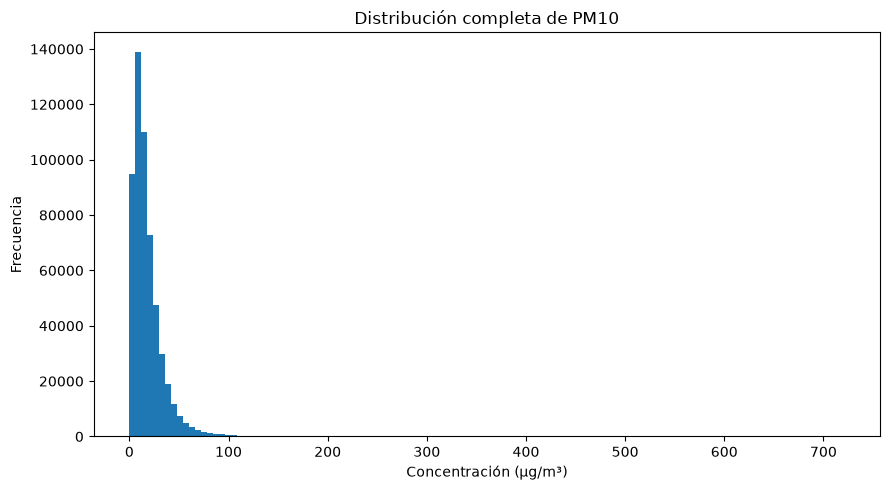

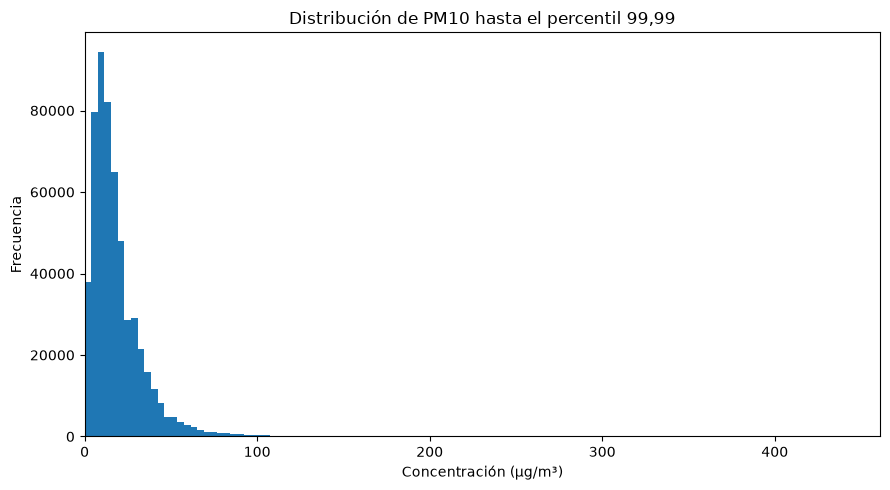

PM2.5
P99.99 = 105.00 µg/m³ | Máximo = 146.00 µg/m³


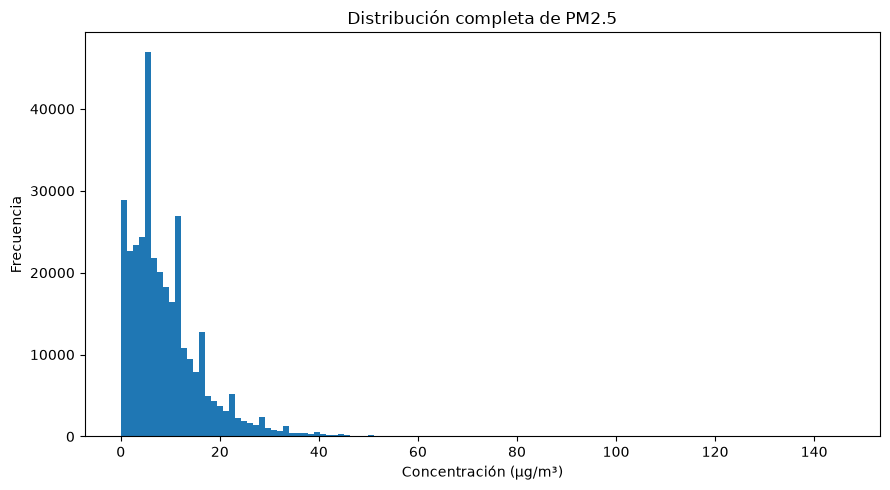

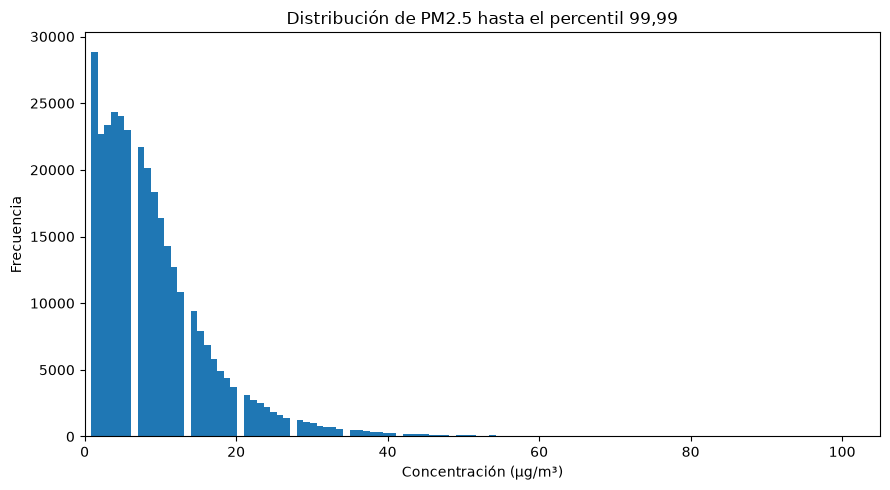

NO₂
P99.99 = 181.00 µg/m³ | Máximo = 248.00 µg/m³


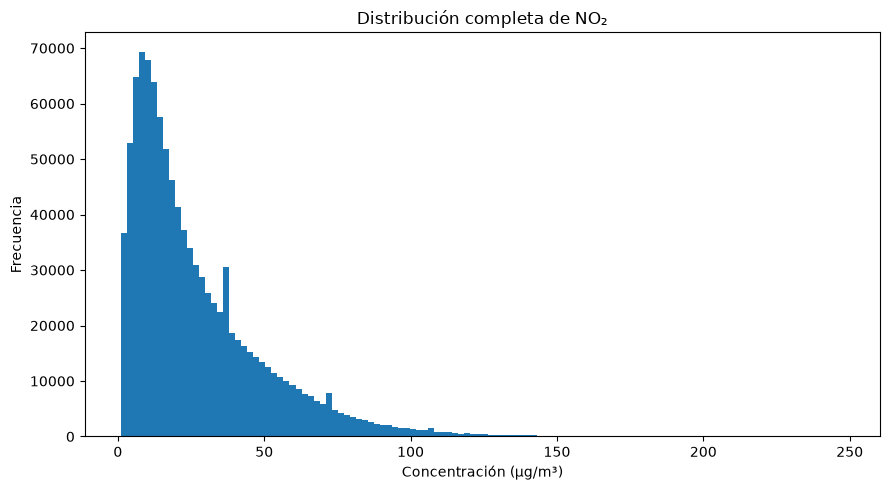

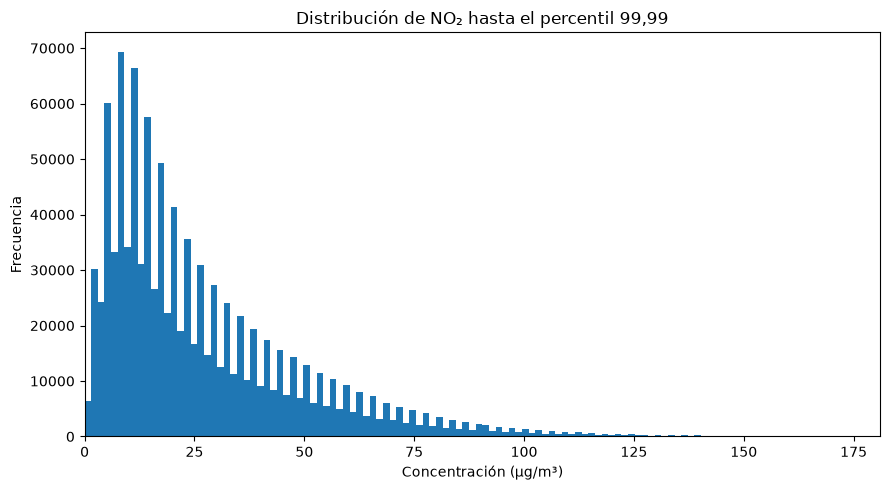

NOx
P99.99 = 643.00 µg/m³ NO₂ | Máximo = 853.00 µg/m³ NO₂


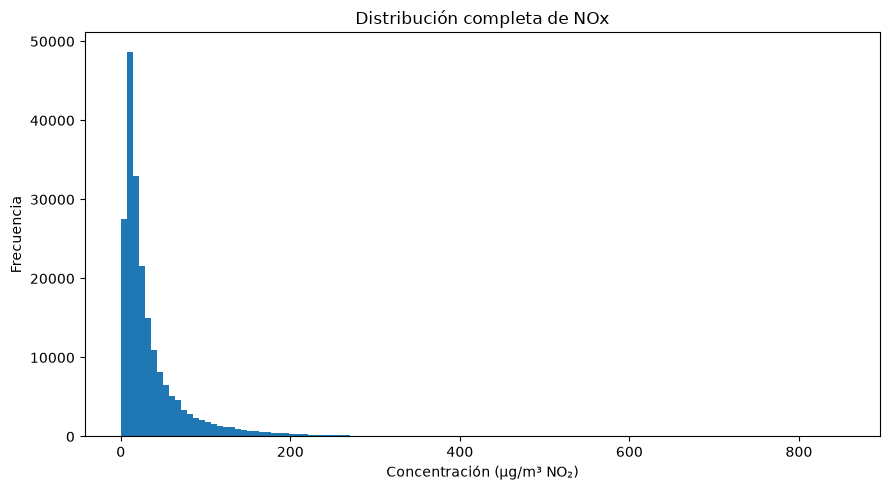

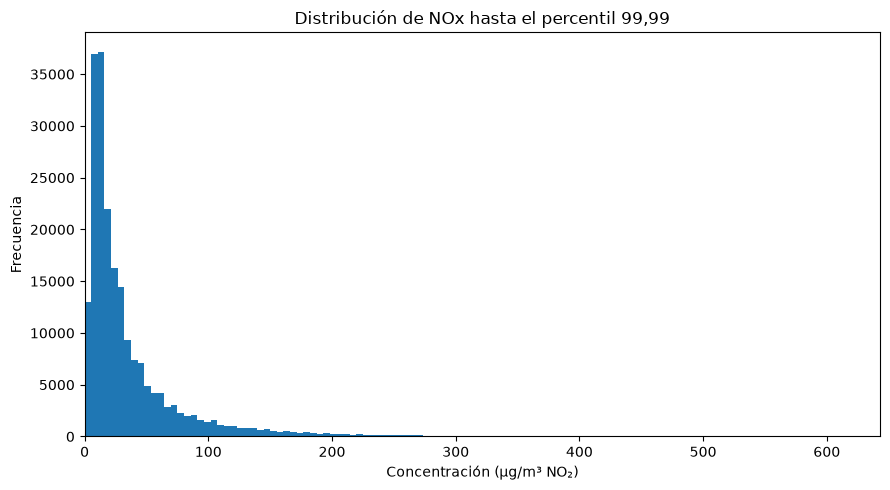

In [11]:
# Distribución de los principales contaminantes (Madrid)

contaminantes = {
    10: ("PM10", "µg/m³"),
    9: ("PM2.5", "µg/m³"),
    8: ("NO₂", "µg/m³"),
    12: ("NOx", "µg/m³ NO₂"),
}

for magnitud, (nombre, unidad) in contaminantes.items():

    valores = (
        aire_madrid
        .filter(pl.col("magnitud") == magnitud)
        .select("uom_value")
        .collect()
        .to_series()
    )

    p9999 = valores.quantile(0.9999)
    maximo = valores.max()

    print("=" * 80)
    print(f"{nombre}")
    print(f"P99.99 = {p9999:.2f} {unidad} | Máximo = {maximo:.2f} {unidad}")

    # Distribución completa
    plt.figure(figsize=(9,5))
    plt.hist(valores, bins=120)
    plt.title(f"Distribución completa de {nombre}")
    plt.xlabel(f"Concentración ({unidad})")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

    # Distribución hasta el P99.99
    plt.figure(figsize=(9,5))
    plt.hist(
        valores,
        bins=120,
        range=(0, p9999)
    )
    plt.title(f"Distribución de {nombre} hasta el percentil 99,99")
    plt.xlabel(f"Concentración ({unidad})")
    plt.ylabel("Frecuencia")
    plt.xlim(0, p9999)
    plt.tight_layout()
    plt.show()

#### Interpretación

Los histogramas muestran que todos los contaminantes analizados presentan distribuciones claramente asimétricas hacia la derecha, un comportamiento habitual en variables relacionadas con la calidad del aire debido a la existencia de episodios puntuales de elevada contaminación.

Aunque algunos contaminantes, como PM₁₀ y NOx, presentan colas más largas que el resto, la transición desde las concentraciones habituales hasta los valores máximos se produce de forma continua, sin observarse saltos bruscos, grupos aislados de observaciones o patrones que sugieran errores sistemáticos de medida.

Asimismo, los pequeños picos observados en algunas distribuciones, especialmente en PM₂.₅ y NO₂, son compatibles con la discretización o resolución de los instrumentos de medida y no constituyen indicios de anomalías.

En conjunto, el análisis visual confirma que la mayoría de los valores identificados previamente mediante el criterio IQR corresponden a episodios reales de contaminación y no a errores evidentes del conjunto de datos. Por este motivo, en esta fase no se considera justificada la eliminación automática de dichos registros, manteniéndose para preservar la variabilidad natural del fenómeno estudiado.

### 2.3.4 Comparación de la distribución de los principales contaminantes

Como complemento a los histogramas individuales, se representa un diagrama de cajas para los principales contaminantes del municipio de Madrid.

Dado que las concentraciones presentan órdenes de magnitud muy diferentes, se utiliza una escala logarítmica en el eje vertical con el fin de facilitar la comparación entre distribuciones. Además, se ocultan los valores atípicos para centrar el análisis en la posición, dispersión y rango intercuartílico de cada contaminante.

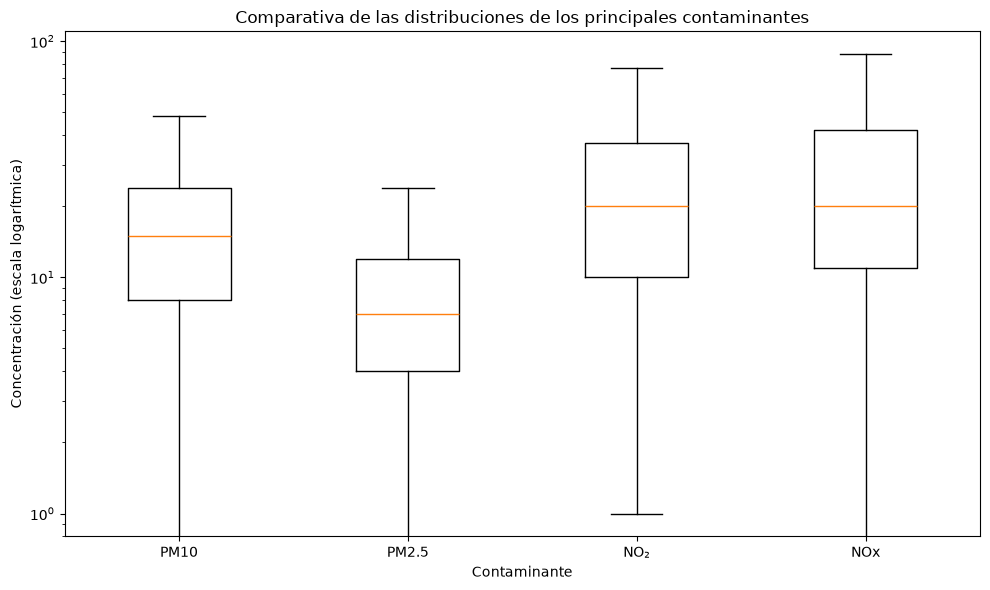

In [12]:
# Comparativa de distribuciones mediante boxplot (Madrid)

contaminantes = {
    10: "PM10",
    9: "PM2.5",
    8: "NO₂",
    12: "NOx",
}

datos = []
etiquetas = []

for magnitud, nombre in contaminantes.items():

    valores = (
        aire_madrid
        .filter(pl.col("magnitud") == magnitud)
        .select("uom_value")
        .collect()
        .to_series()
        .to_list()
    )

    datos.append(valores)
    etiquetas.append(nombre)

plt.figure(figsize=(10,6))

plt.boxplot(
    datos,
    tick_labels=etiquetas,
    showfliers=False
)

plt.yscale("log")

plt.title("Comparativa de las distribuciones de los principales contaminantes")
plt.xlabel("Contaminante")
plt.ylabel("Concentración (escala logarítmica)")

plt.tight_layout()
plt.show()


#### Interpretación

El diagrama de cajas confirma las diferencias observadas en los histogramas individuales. PM₂.₅ presenta la distribución más compacta y las menores concentraciones características, mientras que PM₁₀ muestra una mayor dispersión asociada a episodios puntuales de elevada concentración.

Por su parte, NO₂ y NOx presentan tanto las mayores medianas como la mayor variabilidad, lo que resulta coherente con la elevada influencia del tráfico rodado sobre estos contaminantes en un entorno urbano como el municipio de Madrid.

La utilización de una escala logarítmica permite comparar simultáneamente contaminantes con órdenes de magnitud diferentes, evitando que las distribuciones de menor amplitud queden ocultas por aquellas con valores más elevados.

En conjunto, el boxplot respalda las conclusiones obtenidas previamente mediante los histogramas, confirmando que las diferencias observadas responden principalmente a la propia naturaleza de cada contaminante y no a la presencia de valores claramente anómalos.

## 2.4 Análisis temporal

Una vez analizada la distribución de los principales contaminantes y evaluada la presencia de valores atípicos, se estudia su comportamiento temporal en el municipio de Madrid.

El objetivo de esta sección es identificar posibles tendencias a largo plazo, patrones estacionales y ciclos asociados a la actividad urbana. Además, este análisis permitirá justificar posteriormente la creación de variables temporales y la agregación de las observaciones horarias a frecuencia diaria para el desarrollo de los modelos predictivos.

### 2.4.1 Disponibilidad temporal de las variables

Antes de estudiar la evolución temporal de los contaminantes, resulta necesario comprobar su disponibilidad durante todo el periodo de estudio (2020–2024).

Esta comprobación permite detectar posibles cambios en la red de monitorización o en las magnitudes publicadas que puedan afectar a la comparabilidad entre años. Para garantizar un análisis homogéneo, únicamente se considerarán aquellas variables con observaciones disponibles durante todo el periodo analizado.

In [13]:
# Disponibilidad temporal de los contaminantes

disponibilidad = (
    aire_madrid
    .with_columns(
        pl.col("fecha").dt.year().alias("anio")
    )
    .group_by(["anio", "magnitud"])
    .agg(
        pl.len().alias("n_registros")
    )
    .join(
        seed_aire.lazy().select([
            "MAGNITUD",
            "NOMBRE",
            "ABREVIATURA"
        ]),
        left_on="magnitud",
        right_on="MAGNITUD",
        how="left"
    )
    .select([
        "anio",
        "ABREVIATURA",
        "NOMBRE",
        "n_registros"
    ])
    .sort(["ABREVIATURA", "anio"])
    .collect()
)

disponibilidad

anio,ABREVIATURA,NOMBRE,n_registros
i32,str,str,u32
2020,"""C6H6""","""BENCENO""",51666
2021,"""C6H6""","""BENCENO""",49404
2022,"""C6H6""","""BENCENO""",50305
2023,"""C6H6""","""BENCENO""",49038
2024,"""C6H6""","""BENCENO""",41833
2020,"""CO""","""MONÓXIDO DE CARBONO""",32830
2021,"""CO""","""MONÓXIDO DE CARBONO""",32036
2022,"""CO""","""MONÓXIDO DE CARBONO""",31578
2023,"""CO""","""MONÓXIDO DE CARBONO""",32677


#### Interpretación

La disponibilidad temporal de las variables muestra que la mayoría de los contaminantes presentan observaciones continuas durante todo el periodo 2020–2024. Sin embargo, se identifican algunas excepciones relevantes.

En particular, **NO** únicamente dispone de registros a partir de 2023, mientras que **NOx** únicamente está disponible durante 2024. Asimismo, determinadas magnitudes auxiliares (M20, M35, M42 y M44) dejan de registrarse en los últimos años del periodo analizado.

Con el objetivo de garantizar la comparabilidad entre años, el análisis temporal se realizará únicamente sobre aquellos contaminantes con cobertura completa durante todo el periodo de estudio: **PM₁₀, PM₂.₅, NO₂ y O₃**.

### 2.4.2 Evolución anual

Una vez identificados los contaminantes con disponibilidad completa durante todo el periodo de estudio, se analiza la evolución de sus concentraciones medias anuales.

Con el objetivo de facilitar la comparación entre contaminantes, la evolución de **PM₁₀, PM₂.₅, NO₂ y O₃** se representa en una única figura, permitiendo observar de forma conjunta las tendencias registradas entre 2020 y 2024.

Este análisis permite identificar posibles cambios en la calidad del aire a lo largo del periodo de estudio y detectar variaciones que puedan estar asociadas a modificaciones en las emisiones, la actividad urbana o las condiciones meteorológicas.

In [14]:
# Evolución anual de los principales contaminantes (2020-2024)

contaminantes_temporales = {
    10: "PM10",
    9: "PM2.5",
    8: "NO₂",
    14: "O₃",
}

evolucion_anual = (
    aire_madrid
    .filter(pl.col("magnitud").is_in(list(contaminantes_temporales.keys())))
    .with_columns(
        pl.col("fecha").dt.year().alias("anio")
    )
    .group_by(["anio", "magnitud"])
    .agg(
        pl.col("uom_value").mean().alias("media")
    )
    .collect()
    .with_columns(
        pl.col("magnitud")
        .replace_strict(contaminantes_temporales)
        .alias("contaminante")
    )
    .sort(["contaminante", "anio"])
)

evolucion_anual

anio,magnitud,media,contaminante
i32,i64,f64,str
2020,8,27.212282,"""NO₂"""
2021,8,28.890008,"""NO₂"""
2022,8,28.215414,"""NO₂"""
2023,8,27.527026,"""NO₂"""
2024,8,23.186486,"""NO₂"""
2020,14,50.991191,"""O₃"""
2021,14,51.43359,"""O₃"""
2022,14,52.300488,"""O₃"""
2023,14,56.186493,"""O₃"""


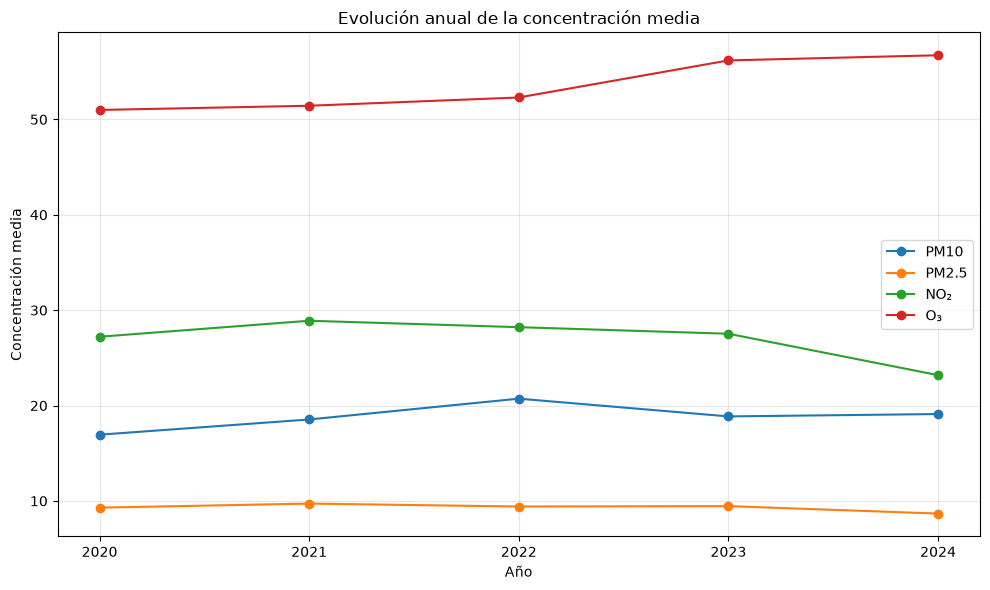

In [15]:
plt.figure(figsize=(10,6))

for contaminante in contaminantes_temporales.values():

    datos = (
        evolucion_anual
        .filter(pl.col("contaminante") == contaminante)
        .sort("anio")
    )

    plt.plot(
        datos["anio"].to_list(),
        datos["media"].to_list(),
        marker="o",
        label=contaminante
    )

plt.title("Evolución anual de la concentración media")
plt.xlabel("Año")
plt.ylabel("Concentración media")
plt.xticks([2020,2021,2022,2023,2024])

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Interpretación

La evolución anual muestra un comportamiento relativamente estable para los principales contaminantes durante el periodo 2020–2024.

Las concentraciones medias de **PM₁₀** y **PM₂.₅** presentan únicamente pequeñas variaciones interanuales, sin apreciarse una tendencia claramente creciente o decreciente. En el caso de PM₁₀ se observa un ligero incremento hasta 2022, seguido de una estabilización en los años posteriores.

Por su parte, **NO₂** mantiene valores similares entre 2020 y 2023, registrando un descenso en 2024. En sentido contrario, **O₃** muestra una ligera tendencia creciente a lo largo del periodo analizado, alcanzando sus mayores concentraciones medias en los dos últimos años.

En conjunto, las diferencias observadas entre años son moderadas, lo que sugiere una evolución relativamente estable de la calidad del aire en el municipio de Madrid durante el periodo de estudio.

### 2.4.3 Evolución mensual

Tras analizar la evolución anual, se estudia el comportamiento medio de los principales contaminantes a lo largo de los meses del año.

Para ello, se agrupan conjuntamente las observaciones de todos los años disponibles (2020–2024), obteniendo así el perfil mensual medio de cada contaminante. Este análisis permite identificar patrones estacionales y detectar posibles diferencias entre los meses más fríos y los más cálidos.

Con el fin de facilitar la interpretación, cada contaminante se representa en un gráfico independiente dentro de una misma figura.

In [16]:
# Evolución mensual media (2020-2024)

perfil_mensual = (
    aire_madrid
    .filter(
        pl.col("magnitud").is_in(list(contaminantes_temporales.keys()))
    )
    .with_columns(
        pl.col("fecha").dt.month().alias("mes")
    )
    .group_by(["mes", "magnitud"])
    .agg(
        pl.col("uom_value").mean().alias("media")
    )
    .collect()
    .with_columns(
        pl.col("magnitud")
        .replace_strict(contaminantes_temporales)
        .alias("contaminante")
    )
    .sort(["contaminante", "mes"])
)

perfil_mensual

mes,magnitud,media,contaminante
i8,i64,f64,str
1,8,41.116975,"""NO₂"""
2,8,37.028915,"""NO₂"""
3,8,25.4577,"""NO₂"""
4,8,19.745023,"""NO₂"""
5,8,16.656288,"""NO₂"""
6,8,18.398337,"""NO₂"""
7,8,20.260548,"""NO₂"""
8,8,19.565209,"""NO₂"""
9,8,25.024536,"""NO₂"""


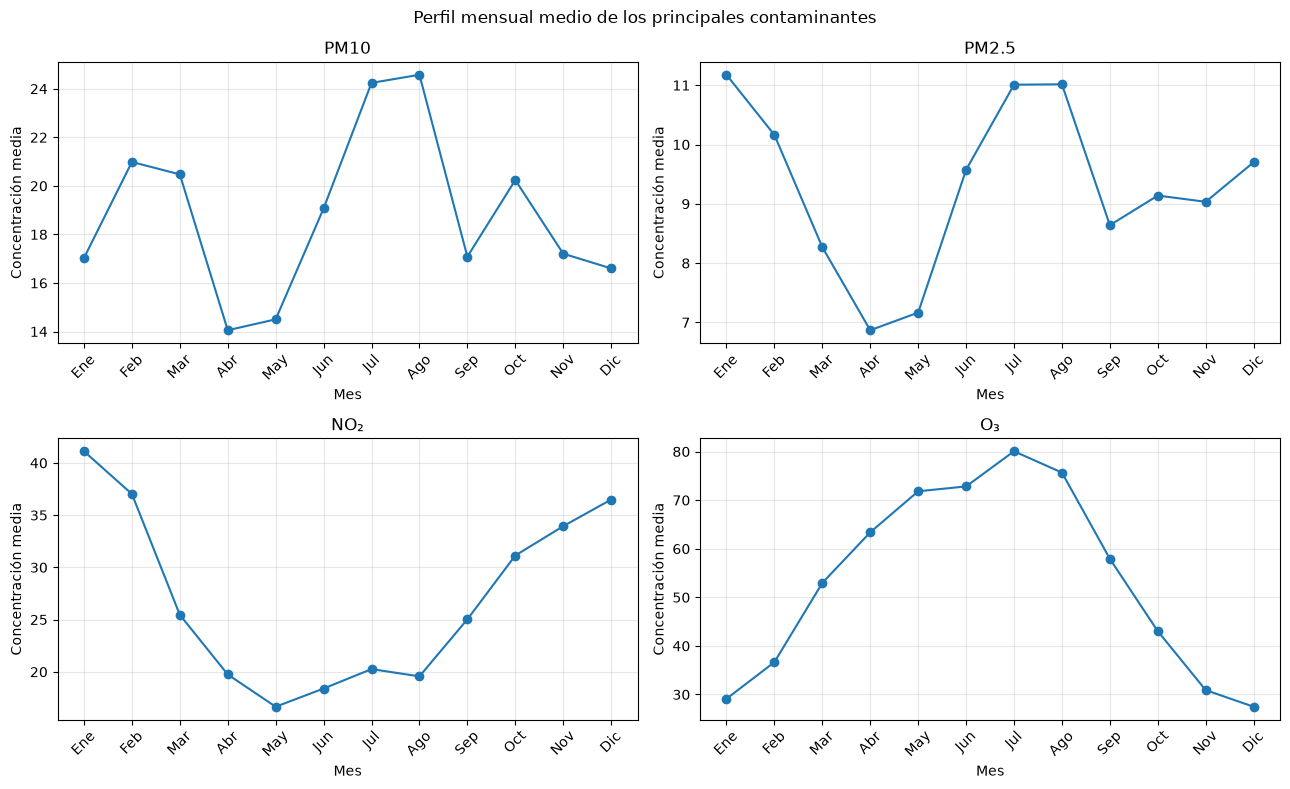

In [17]:
nombres_meses = [
    "Ene","Feb","Mar","Abr","May","Jun",
    "Jul","Ago","Sep","Oct","Nov","Dic"
]

fig, axs = plt.subplots(2, 2, figsize=(13, 8))

for ax, contaminante in zip(axs.flat, contaminantes_temporales.values()):

    datos = (
        perfil_mensual
        .filter(pl.col("contaminante") == contaminante)
        .sort("mes")
    )

    ax.plot(
        datos["mes"].to_list(),
        datos["media"].to_list(),
        marker="o"
    )

    ax.set_title(contaminante)
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(nombres_meses, rotation=45)
    ax.set_xlabel("Mes")
    ax.set_ylabel("Concentración media")
    ax.grid(alpha=0.3)

plt.suptitle("Perfil mensual medio de los principales contaminantes")

plt.tight_layout()
plt.show()

#### Interpretación

El análisis mensual pone de manifiesto la existencia de una marcada estacionalidad en los principales contaminantes atmosféricos.

El **NO₂** presenta las mayores concentraciones durante los meses de invierno, disminuyendo progresivamente hasta alcanzar sus valores mínimos entre finales de primavera y verano. Este comportamiento resulta coherente con la mayor estabilidad atmosférica de los meses fríos y con la mayor intensidad del tráfico tras el periodo estival.

Por el contrario, el **O₃** muestra una evolución prácticamente inversa, registrando sus máximas concentraciones durante los meses de verano. Este patrón es consistente con los procesos fotoquímicos responsables de la formación del ozono troposférico, favorecidos por una mayor radiación solar.

Las partículas **PM₁₀** y **PM₂.₅** también presentan variaciones estacionales, aunque menos definidas. Ambas muestran incrementos durante los meses estivales, compatibles con episodios de resuspensión de partículas o intrusiones de polvo mineral, así como concentraciones relativamente elevadas durante algunos meses de invierno.

En conjunto, los resultados ponen de manifiesto una clara componente estacional en las concentraciones de los principales contaminantes, lo que justifica la incorporación de variables temporales como el mes del año en las etapas posteriores del modelado.

### 2.4.4 Evolución semanal

Además de la estacionalidad anual, resulta de interés analizar si las concentraciones de los contaminantes presentan diferencias según el día de la semana.

Este análisis permite identificar patrones asociados a la actividad urbana, especialmente al tráfico rodado, cuya intensidad suele variar entre los días laborables y los fines de semana.

Para ello se calcula la concentración media de cada contaminante para cada día de la semana considerando conjuntamente todo el periodo de estudio.

In [18]:
# Evolución semanal de los principales contaminantes

perfil_semanal = (
    aire_madrid
    .filter(
        pl.col("magnitud").is_in(list(contaminantes_temporales.keys()))
    )
    .with_columns(
        pl.col("fecha").dt.weekday().alias("dia_semana")
    )
    .group_by(["dia_semana", "magnitud"])
    .agg(
        pl.col("uom_value").mean().alias("media")
    )
    .collect()
    .with_columns(
        pl.col("magnitud")
        .replace_strict(contaminantes_temporales)
        .alias("contaminante")
    )
    .sort(["contaminante", "dia_semana"])
)

perfil_semanal

dia_semana,magnitud,media,contaminante
i8,i64,f64,str
1,8,27.369573,"""NO₂"""
2,8,29.688189,"""NO₂"""
3,8,29.121933,"""NO₂"""
4,8,29.385272,"""NO₂"""
5,8,28.331866,"""NO₂"""
6,8,23.970303,"""NO₂"""
7,8,21.152279,"""NO₂"""
1,14,52.811343,"""O₃"""
2,14,50.840379,"""O₃"""


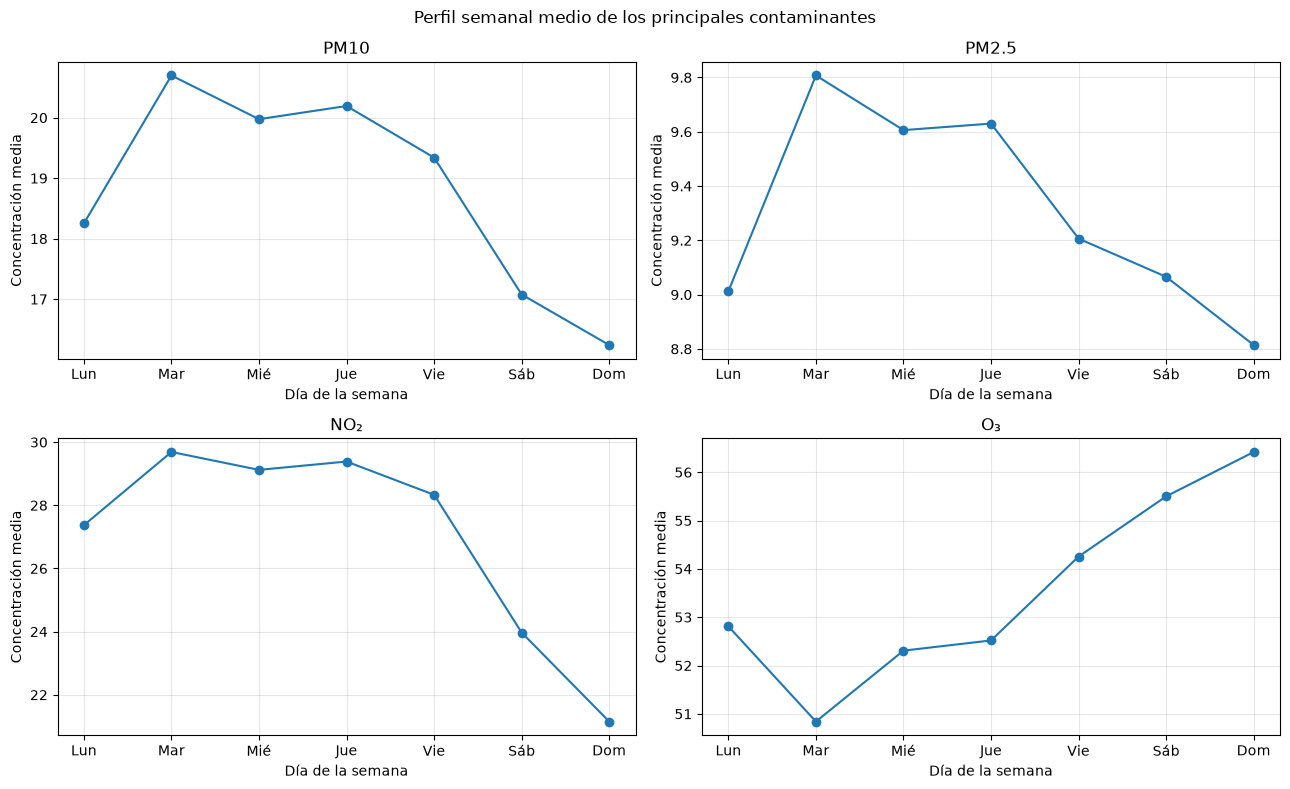

In [19]:
dias = [
    "Lun", "Mar", "Mié", "Jue",
    "Vie", "Sáb", "Dom"
]

fig, axs = plt.subplots(2, 2, figsize=(13, 8))

for ax, contaminante in zip(axs.flat, contaminantes_temporales.values()):

    datos = (
        perfil_semanal
        .filter(pl.col("contaminante") == contaminante)
        .sort("dia_semana")
    )

    ax.plot(
        datos["dia_semana"].to_list(),
        datos["media"].to_list(),
        marker="o"
    )

    ax.set_title(contaminante)
    ax.set_xticks(range(1, 8))
    ax.set_xticklabels(dias)
    ax.set_xlabel("Día de la semana")
    ax.set_ylabel("Concentración media")
    ax.grid(alpha=0.3)

plt.suptitle("Perfil semanal medio de los principales contaminantes")

plt.tight_layout()
plt.show()

#### Interpretación

El análisis semanal evidencia un patrón claramente diferenciado entre los contaminantes asociados al tráfico y el ozono.

Las concentraciones medias de **PM₁₀**, **PM₂.₅** y especialmente **NO₂** son mayores durante los días laborables, alcanzando sus valores máximos entre martes y jueves. A partir del viernes se observa un descenso progresivo, que se acentúa durante el fin de semana y alcanza su mínimo el domingo.

Por el contrario, **O₃** presenta un comportamiento inverso, registrando las menores concentraciones durante los días laborables y aumentando progresivamente durante el fin de semana, con un máximo el domingo.

Estos resultados son coherentes con la influencia de la actividad urbana y del tráfico rodado sobre las concentraciones de contaminantes primarios, así como con la formación fotoquímica del ozono troposférico.

La existencia de este patrón semanal pone de manifiesto la conveniencia de incorporar variables temporales relacionadas con el día de la semana o la diferenciación entre días laborables y fines de semana en las etapas posteriores del modelado.

### 2.4.5 Evolución horaria

Por último, se analiza la evolución media de las concentraciones a lo largo de las 24 horas del día.

El estudio del patrón horario permite identificar posibles ciclos diarios asociados a la actividad urbana, especialmente al tráfico rodado, así como a la evolución de las condiciones atmosféricas durante el día.

Este análisis resulta especialmente relevante dado que el conjunto de datos será posteriormente agregado a frecuencia diaria para el entrenamiento de los modelos predictivos. Por ello, permite conocer qué información temporal se pierde durante dicho proceso de agregación.

In [20]:
# Evolución horaria de los principales contaminantes

perfil_horario = (
    aire_madrid
    .filter(
        pl.col("magnitud").is_in(list(contaminantes_temporales.keys()))
    )
    .with_columns(
        pl.col("fecha").dt.hour().alias("hora")
    )
    .group_by(["hora", "magnitud"])
    .agg(
        pl.col("uom_value").mean().alias("media")
    )
    .collect()
    .with_columns(
        pl.col("magnitud")
        .replace_strict(contaminantes_temporales)
        .alias("contaminante")
    )
    .sort(["contaminante", "hora"])
)

perfil_horario

hora,magnitud,media,contaminante
i8,i64,f64,str
0,8,22.959304,"""NO₂"""
1,8,19.778293,"""NO₂"""
2,8,17.962536,"""NO₂"""
3,8,17.696022,"""NO₂"""
4,8,20.862281,"""NO₂"""
5,8,28.859536,"""NO₂"""
6,8,35.277449,"""NO₂"""
7,8,35.567955,"""NO₂"""
8,8,31.462891,"""NO₂"""


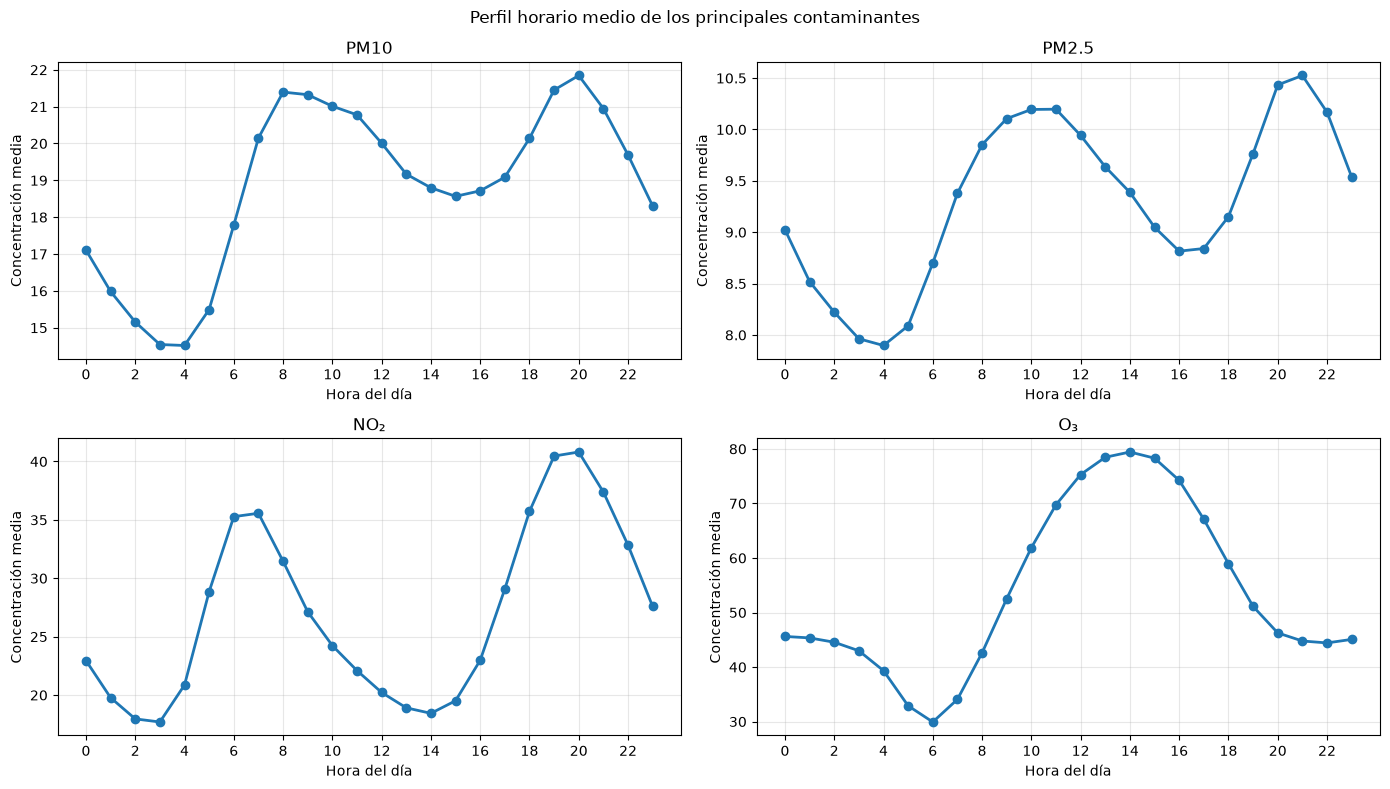

In [21]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

for ax, contaminante in zip(axs.flat, contaminantes_temporales.values()):

    datos = (
        perfil_horario
        .filter(pl.col("contaminante") == contaminante)
        .sort("hora")
    )

    ax.plot(
        datos["hora"].to_list(),
        datos["media"].to_list(),
        marker="o",
        linewidth=2
    )

    ax.set_title(contaminante)
    ax.set_xlabel("Hora del día")
    ax.set_ylabel("Concentración media")
    ax.set_xticks(range(0,24,2))
    ax.grid(alpha=0.3)

plt.suptitle("Perfil horario medio de los principales contaminantes")

plt.tight_layout()

plt.show()

#### Interpretación

El análisis horario muestra patrones diarios muy marcados en todos los contaminantes estudiados.

Las concentraciones de **PM₁₀**, **PM₂.₅** y especialmente **NO₂** presentan mínimos durante la madrugada y aumentan de forma notable a partir de las primeras horas de la mañana. En el caso del NO₂ se identifican claramente dos máximos diarios: uno durante la franja matinal y otro, aún más acusado, al final de la tarde, coincidiendo con los periodos de mayor intensidad del tráfico urbano.

Las partículas PM₁₀ y PM₂.₅ siguen un comportamiento similar, aunque con variaciones más suaves, mostrando también incrementos durante las horas de mayor actividad de la ciudad.

Por el contrario, **O₃** presenta un patrón claramente inverso. Sus concentraciones son mínimas durante la madrugada y primeras horas de la mañana, aumentando progresivamente hasta alcanzar su máximo alrededor del mediodía y primeras horas de la tarde, cuando la radiación solar favorece los procesos fotoquímicos responsables de su formación.

Estos resultados ponen de manifiesto la fuerte dependencia temporal de los contaminantes respecto a la actividad urbana y las condiciones atmosféricas, confirmando la relevancia de las variables temporales en la explicación de la variabilidad observada. Asimismo, permiten anticipar que la agregación de las observaciones horarias a frecuencia diaria simplificará el comportamiento temporal de las series, eliminando parte de esta variabilidad intradiaria.

## 2.5 Relación entre los principales contaminantes

Inicialmente se planteó realizar un análisis de correlación entre los principales contaminantes atmosféricos (PM₁₀, PM₂.₅, NO₂ y O₃) con el objetivo de estudiar la relación existente entre ellos.

Sin embargo, durante la construcción del conjunto de datos en formato ancho se comprobó que no todas las estaciones de la red de vigilancia del municipio de Madrid monitorizan los mismos contaminantes. Como consecuencia, para una misma estación y un mismo instante temporal existen variables que no disponen de observación, no debido a valores perdidos, sino porque determinados sensores no están instalados en todas las estaciones.

Esto implica que una matriz de correlación convencional requeriría eliminar un elevado número de observaciones o limitar el análisis únicamente a las estaciones que registran simultáneamente todos los contaminantes considerados, reduciendo considerablemente la representatividad del conjunto de datos respecto al municipio de Madrid.

Aunque sería posible calcular correlaciones utilizando únicamente los pares de observaciones disponibles para cada combinación de contaminantes, dichos coeficientes se obtendrían sobre subconjuntos de estaciones diferentes, dificultando su comparación e interpretación conjunta.

Además, gran parte de la información que podría aportar este análisis ya ha quedado reflejada en las secciones anteriores del EDA. Los análisis de evolución anual, mensual, semanal y horaria han permitido identificar patrones comunes entre contaminantes, así como comportamientos claramente opuestos, como el observado entre NO₂ y O₃. Estas relaciones temporales proporcionan una interpretación más rica que un único coeficiente de correlación, al mostrar cómo varían conjuntamente las concentraciones en distintas escalas temporales.

Por otra parte, el objetivo principal de este trabajo consiste en analizar la influencia de las variables meteorológicas sobre la calidad del aire y desarrollar modelos predictivos de las concentraciones de contaminantes. En este contexto, resulta más relevante estudiar posteriormente la relación entre las variables meteorológicas y los contaminantes una vez construido el conjunto de datos final, ya que dichas correlaciones aportarán información directamente útil para el modelado.

Por estos motivos, se considera que un análisis de correlación entre contaminantes en esta fase aportaría un valor limitado y podría conducir a interpretaciones poco representativas del conjunto del municipio de Madrid. En consecuencia, se decide no incluir este análisis dentro del EDA y centrar el estudio en las relaciones entre contaminación y meteorología tras el proceso de integración de datos.

## 2.6 Análisis espacial

Además del comportamiento temporal, resulta necesario analizar cómo varían las concentraciones de contaminantes entre las distintas estaciones de medida del municipio de Madrid.

Las estaciones de la red de vigilancia se encuentran distribuidas por diferentes zonas de la ciudad y presentan características muy distintas en función de su entorno (tráfico, áreas residenciales, parques urbanos, etc.). Como consecuencia, es esperable que existan diferencias espaciales en los niveles de contaminación registrados.

En esta sección se estudia la distribución espacial de los principales contaminantes mediante el análisis de las concentraciones medias registradas en cada estación de medida.

### 2.6.1 Concentración media por estación

Como primera aproximación al análisis espacial, se calcula la concentración media de cada contaminante en cada una de las estaciones de medida de Madrid.

Este análisis permite identificar diferencias espaciales entre estaciones, detectar aquellas con mayores niveles de contaminación y evaluar la variabilidad existente dentro de la red de vigilancia.

In [22]:
# Estadísticas descriptivas por estación y contaminante

media_estaciones = (
    aire_madrid
    .filter(
        pl.col("magnitud").is_in(list(contaminantes_temporales.keys()))
    )
    .group_by(["estacion", "magnitud"])
    .agg([
        pl.col("uom_value").mean().alias("media"),
        pl.col("uom_value").median().alias("mediana"),
        pl.col("uom_value").std().alias("desviacion_tipica"),
        pl.len().alias("n_registros")
    ])
    .collect()
    .with_columns(
        pl.col("magnitud")
        .replace_strict(contaminantes_temporales)
        .alias("contaminante")
    )
    .select([
        "estacion",
        "contaminante",
        "media",
        "mediana",
        "desviacion_tipica",
        "n_registros"
    ])
    .sort(
        ["contaminante", "media"],
        descending=[False, True]
    )
)

media_estaciones

estacion,contaminante,media,mediana,desviacion_tipica,n_registros
i64,str,f64,f64,f64,u32
56,"""NO₂""",37.523114,32.0,25.612674,43308
17,"""NO₂""",33.473301,24.0,27.618611,43448
8,"""NO₂""",33.005413,27.0,22.090628,43232
11,"""NO₂""",30.441677,23.0,25.389743,42196
50,"""NO₂""",29.865222,24.0,21.711106,43516
35,"""NO₂""",29.667591,24.0,20.636741,41488
40,"""NO₂""",29.574758,22.0,23.43075,43554
38,"""NO₂""",29.540404,21.0,24.575918,43436
27,"""NO₂""",29.52741,23.0,23.495576,43524


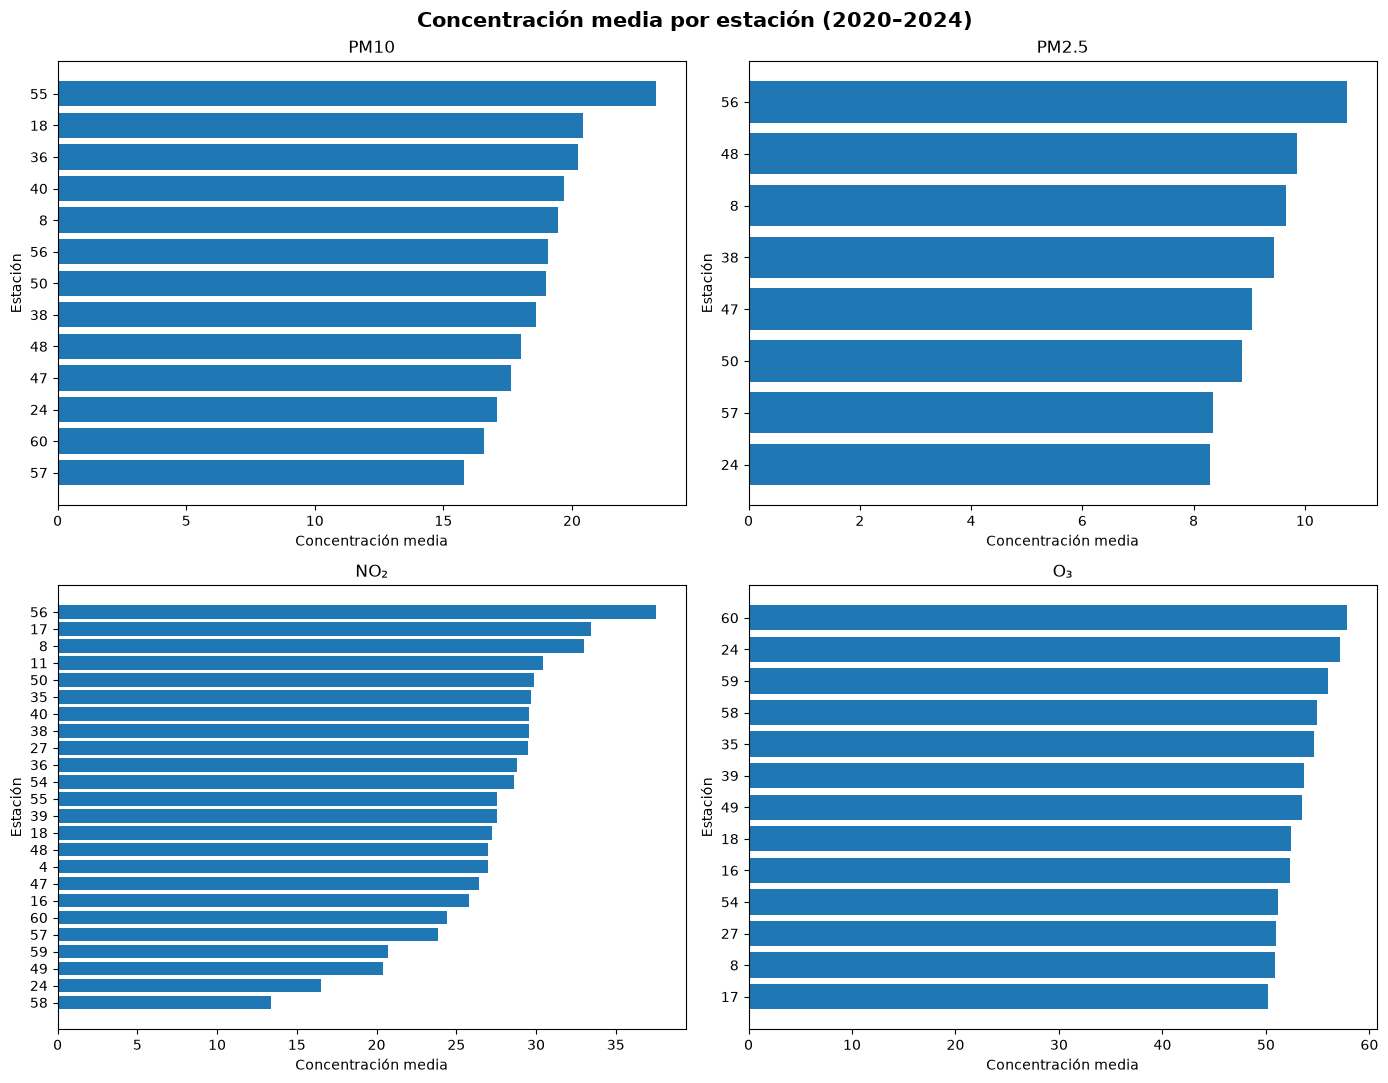

In [23]:
fig, axs = plt.subplots(2, 2, figsize=(14, 11))

for ax, contaminante in zip(axs.flat, contaminantes_temporales.values()):

    datos = (
        media_estaciones
        .filter(
            pl.col("contaminante") == contaminante
        )
        .sort("media")
    )

    ax.barh(
        datos["estacion"].cast(str).to_list(),
        datos["media"].to_list()
    )

    ax.set_title(contaminante, fontsize=12)
    ax.set_xlabel("Concentración media")
    ax.set_ylabel("Estación")

plt.suptitle(
    "Concentración media por estación (2020–2024)",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

#### Interpretación

La concentración media presenta diferencias apreciables entre las estaciones de medida para todos los contaminantes analizados, lo que pone de manifiesto la existencia de una componente espacial en la calidad del aire del municipio de Madrid.

En el caso de **PM₁₀**, **PM₂.₅** y **NO₂** se observa una mayor heterogeneidad entre estaciones, existiendo emplazamientos que registran concentraciones medias significativamente superiores al resto. Estas diferencias pueden estar relacionadas con las características del entorno de cada estación, especialmente la intensidad del tráfico y la proximidad a focos emisores.

Por el contrario, **O₃** muestra una distribución espacial más homogénea, con diferencias relativamente reducidas entre estaciones. Este comportamiento resulta coherente con el carácter secundario del ozono troposférico y con una menor influencia de fuentes locales de emisión.

Asimismo, debe tenerse en cuenta que no todas las estaciones de la red de vigilancia monitorizan los mismos contaminantes, motivo por el cual el número de estaciones representadas varía entre gráficos.

### 2.6.2 Variabilidad entre estaciones

Además de comparar las concentraciones medias registradas en cada estación, resulta de interés analizar la variabilidad temporal de las medidas.

Para ello se estudia la desviación típica de las concentraciones registradas en cada estación, lo que permite identificar aquellas ubicaciones que presentan una mayor fluctuación de los niveles de contaminación a lo largo del periodo de estudio.

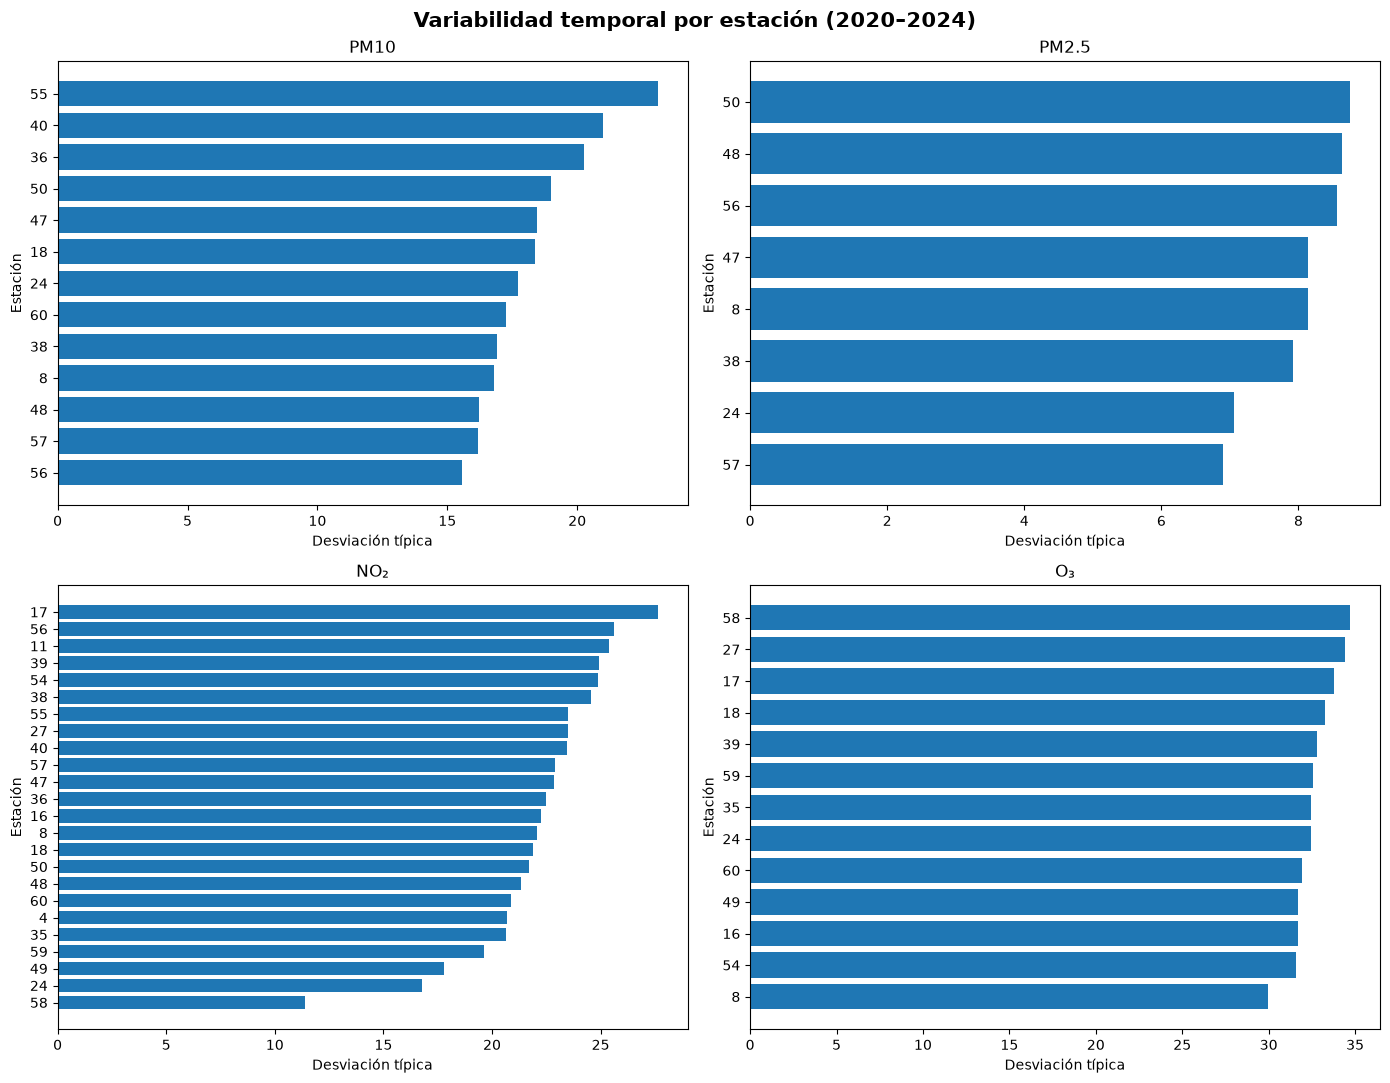

In [24]:
fig, axs = plt.subplots(2, 2, figsize=(14, 11))

for ax, contaminante in zip(axs.flat, contaminantes_temporales.values()):

    datos = (
        media_estaciones
        .filter(
            pl.col("contaminante") == contaminante
        )
        .sort("desviacion_tipica")
    )

    ax.barh(
        datos["estacion"].cast(str).to_list(),
        datos["desviacion_tipica"].to_list()
    )

    ax.set_title(contaminante)
    ax.set_xlabel("Desviación típica")
    ax.set_ylabel("Estación")

plt.suptitle(
    "Variabilidad temporal por estación (2020–2024)",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

#### Interpretación

La variabilidad temporal presenta diferencias entre estaciones para todos los contaminantes analizados, aunque estas resultan, en general, menos acusadas que las observadas en las concentraciones medias.

En **PM₁₀** y **NO₂** se identifican algunas estaciones con una desviación típica superior al resto, lo que indica una mayor exposición a episodios de contaminación de elevada intensidad o una mayor fluctuación de las concentraciones a lo largo del periodo de estudio.

Por el contrario, **PM₂.₅** y **O₃** muestran una variabilidad más homogénea entre estaciones, sin diferencias especialmente destacadas. Esto sugiere que, aunque existen diferencias en los niveles medios registrados, la magnitud de las oscilaciones temporales es relativamente similar dentro de la red de vigilancia para estos contaminantes.

En conjunto, estos resultados indican que la principal diferencia entre estaciones radica en los niveles medios de contaminación registrados, mientras que la variabilidad temporal presenta un comportamiento más uniforme.

## 2.7 Conclusiones del análisis exploratorio

El análisis exploratorio realizado sobre los datos de calidad del aire del municipio de Madrid ha permitido caracterizar el conjunto de datos, identificar posibles problemas de calidad y comprender el comportamiento espacial y temporal de los principales contaminantes. A partir de los resultados obtenidos, se establecen las siguientes conclusiones y decisiones metodológicas que servirán de base para el proceso de preprocesado y para el desarrollo de los modelos predictivos.

### Principales hallazgos

- El conjunto de datos presenta una estructura consistente, sin valores nulos en las variables originales analizadas ni registros duplicados, lo que facilita su utilización en las siguientes fases del trabajo.

- Se detectaron valores negativos en algunos contaminantes. Dado que representan concentraciones físicamente imposibles, estos registros se consideran errores de medida y deberán eliminarse durante el preprocesado.

- Las distribuciones de los contaminantes presentan una marcada asimetría positiva y colas largas, especialmente en PM₁₀, PM₂.₅, NO₂ y NOx. Este comportamiento es habitual en variables ambientales, donde la mayoría de observaciones corresponden a situaciones normales y un reducido número de episodios concentra los valores más elevados.

- El análisis mediante el criterio IQR identificó un porcentaje significativo de valores atípicos en algunos contaminantes. Sin embargo, el estudio de percentiles, histogramas y boxplots mostró que estos registros corresponden a episodios reales de contaminación y no a errores de medida, por lo que no se considera adecuado eliminarlos.

- El análisis temporal puso de manifiesto patrones claramente definidos a diferentes escalas. Se observaron variaciones estacionales, diferencias entre días laborables y fines de semana, así como una marcada variación intradiaria, especialmente en contaminantes asociados al tráfico como NO₂ y PM₁₀.

- El ozono (O₃) presentó un comportamiento temporal claramente diferenciado respecto al resto de contaminantes. A diferencia de PM₁₀, PM₂.₅ y NO₂, sus concentraciones aumentan durante los meses cálidos, los fines de semana y las horas centrales del día. Este patrón se debe a que el ozono no se emite directamente por fuentes como el tráfico, sino que se genera en la atmósfera a partir de otros contaminantes cuando existe suficiente radiación solar.

- El análisis espacial evidenció diferencias apreciables entre estaciones en cuanto a las concentraciones medias registradas, mientras que la variabilidad temporal resultó, en general, más homogénea entre ellas.

- Finalmente, se descartó realizar un análisis de correlación entre contaminantes, ya que las distintas estaciones de medida no monitorizan necesariamente las mismas variables, lo que habría reducido considerablemente la representatividad del análisis. Además, las principales relaciones entre contaminantes ya quedaron reflejadas mediante el estudio de sus patrones temporales.

### Decisiones derivadas del EDA

Como consecuencia de los resultados obtenidos durante el análisis exploratorio, se adoptan las siguientes decisiones para el proceso de preprocesado y construcción del conjunto de datos final:

- Restringir el ámbito de estudio exclusivamente al municipio de Madrid, descartando el resto de municipios presentes en el conjunto de datos para centrar el análisis en la ciudad objeto del trabajo.

- Limitar el análisis principal a los contaminantes **PM₁₀, PM₂.₅, NO₂ y O₃**, al ser los únicos que presentan una cobertura temporal homogénea durante todo el periodo de estudio. Las variables **NO** y **NOx** quedan excluidas del análisis principal y del modelado debido a su disponibilidad parcial.

- Eliminar los registros con concentraciones negativas por corresponder a valores físicamente imposibles y atribuibles a errores de medida.

- Mantener los valores atípicos detectados mediante el criterio IQR, al considerarse que representan episodios reales de contaminación y contienen información relevante sobre situaciones excepcionales de calidad del aire.

- Conservar la escala original de las concentraciones, descartando la aplicación de transformaciones logarítmicas u otras técnicas de normalización durante esta fase, al no resultar necesarias para los modelos previstos y facilitar la interpretación de los resultados.

- Agregar las observaciones horarias a resolución diaria durante el proceso de preprocesado. Esta decisión viene motivada por la integración posterior con la información meteorológica, cuya resolución temporal es diaria, permitiendo construir un conjunto de datos homogéneo para el entrenamiento de los modelos predictivos.

- Integrar posteriormente el conjunto de datos de contaminación con las variables meteorológicas disponibles, incorporando información relativa a la temperatura, precipitación, velocidad y dirección del viento, así como el resto de variables meteorológicas que puedan aportar capacidad explicativa al comportamiento de los contaminantes.

- Generar nuevas variables temporales derivadas de la fecha (año, mes, día de la semana, estación del año, fin de semana, festivos y otras variables calendario que resulten relevantes), aprovechando los patrones temporales identificados durante el análisis exploratorio.

- Analizar la relación entre las variables meteorológicas y los contaminantes una vez construido el conjunto de datos final, al tratarse de un análisis directamente alineado con el objetivo del trabajo y con el desarrollo de los modelos predictivos.

## Aspectos pendientes para revisar

- Sustituir los identificadores de las estaciones por sus nombres mediante una tabla de referencia de estaciones.

- Confirmar la incorporación de información adicional de las estaciones (tipo de estación, distrito, etc).

- Revisar el tratamiento de las magnitudes históricas que únicamente aparecen en determinados años. Dado que el análisis y el modelado se centrarán en PM10, PM2.5, NO2 y O3, valorar si estas magnitudes deben excluirse del conjunto de datos de trabajo durante el preprocesado en lugar de mantenerlas en la metadata con la unidad genérica `"unidad"`.

En conjunto, las decisiones adoptadas permiten construir un conjunto de datos consistente, homogéneo y representativo, preservando la información relevante identificada durante el análisis exploratorio y proporcionando una base sólida para las fases posteriores de preprocesado y modelado.

### Identificación de contaminantes con cobertura temporal incompleta

Antes de construir el conjunto de datos final, se comprueba qué contaminantes disponen de observaciones durante todos los años del periodo de estudio.

Se consideran aptos para el análisis longitudinal aquellos contaminantes con registros en cada uno de los años comprendidos entre 2020 y 2024. Las magnitudes con cobertura parcial se identificarán para valorar su exclusión del dataset de modelado.

In [25]:
# Identificación de contaminantes con cobertura temporal completa e incompleta

ANIO_INICIO = 2020
ANIO_FIN = 2024

anios_esperados = list(range(ANIO_INICIO, ANIO_FIN + 1))
n_anios_esperados = len(anios_esperados)

cobertura_contaminantes = (
    aire_madrid
    .with_columns(
        pl.col("fecha").dt.year().alias("anio")
    )
    .group_by("magnitud")
    .agg([
        pl.col("anio").unique().sort().alias("anios_disponibles"),
        pl.col("anio").n_unique().alias("n_anios_disponibles"),
        pl.len().alias("n_registros")
    ])
    .join(
        seed_aire.lazy().select([
            "MAGNITUD",
            "NOMBRE",
            "ABREVIATURA"
        ]),
        left_on="magnitud",
        right_on="MAGNITUD",
        how="left"
    )
    .with_columns([
        (
            pl.col("n_anios_disponibles") == n_anios_esperados
        ).alias("cobertura_completa"),

        pl.lit(anios_esperados)
        .list.set_difference(pl.col("anios_disponibles"))
        .alias("anios_ausentes")
    ])
    .select([
        "magnitud",
        "NOMBRE",
        "ABREVIATURA",
        "anios_disponibles",
        "anios_ausentes",
        "n_anios_disponibles",
        "n_registros",
        "cobertura_completa"
    ])
    .sort(
        ["cobertura_completa", "magnitud"],
        descending=[False, False]
    )
    .collect()
)

print("=" * 100)
print("COBERTURA TEMPORAL DE LOS CONTAMINANTES")
print("=" * 100)

display(cobertura_contaminantes)

COBERTURA TEMPORAL DE LOS CONTAMINANTES


magnitud,NOMBRE,ABREVIATURA,anios_disponibles,anios_ausentes,n_anios_disponibles,n_registros,cobertura_completa
i64,str,str,list[i32],list[i32],u32,u32,bool
7,"""MONÓXIDO DE NITRÓGENO""","""NO""","[2023, 2024]","[2020, 2021, 2022]",2,412029,false
12,"""ÓXIDOS DE NITRÓGENO TOTALES""","""NOX""",[2024],"[2020, 2021, … 2023]",1,208155,false
20,"""DESCONOCIDA""","""M20""","[2020, 2021, … 2023]",[2024],4,199842,false
35,"""DESCONOCIDA""","""M35""","[2020, 2021, … 2023]",[2024],4,198721,false
42,"""DESCONOCIDA""","""M42""",[2020],"[2024, 2021, … 2023]",1,25861,false
44,"""DESCONOCIDA""","""M44""",[2020],"[2024, 2021, … 2023]",1,25859,false
1,"""DIÓXIDO DE AZUFRE""","""SO2""","[2020, 2021, … 2024]",[],5,161030,true
6,"""MONÓXIDO DE CARBONO""","""CO""","[2020, 2021, … 2024]",[],5,163683,true
8,"""DIÓXIDO DE NITRÓGENO""","""NO2""","[2020, 2021, … 2024]",[],5,1028957,true


In [26]:
contaminantes_cobertura_incompleta = (
    cobertura_contaminantes
    .filter(
        pl.col("cobertura_completa") == False
    )
)

print("=" * 100)
print("CONTAMINANTES CON COBERTURA TEMPORAL INCOMPLETA")
print("=" * 100)

display(contaminantes_cobertura_incompleta)

CONTAMINANTES CON COBERTURA TEMPORAL INCOMPLETA


magnitud,NOMBRE,ABREVIATURA,anios_disponibles,anios_ausentes,n_anios_disponibles,n_registros,cobertura_completa
i64,str,str,list[i32],list[i32],u32,u32,bool
7,"""MONÓXIDO DE NITRÓGENO""","""NO""","[2023, 2024]","[2020, 2021, 2022]",2,412029,false
12,"""ÓXIDOS DE NITRÓGENO TOTALES""","""NOX""",[2024],"[2020, 2021, … 2023]",1,208155,false
20,"""DESCONOCIDA""","""M20""","[2020, 2021, … 2023]",[2024],4,199842,false
35,"""DESCONOCIDA""","""M35""","[2020, 2021, … 2023]",[2024],4,198721,false
42,"""DESCONOCIDA""","""M42""",[2020],"[2024, 2021, … 2023]",1,25861,false
44,"""DESCONOCIDA""","""M44""",[2020],"[2024, 2021, … 2023]",1,25859,false


### Justificación de la selección de contaminantes

Tras analizar la cobertura temporal de todas las magnitudes disponibles, el estudio se centrará en **PM₁₀, PM₂.₅, NO₂ y O₃**, ya que son los únicos contaminantes de mayor interés que presentan una cobertura homogénea durante todo el periodo de estudio (2020–2024).

Además de esta disponibilidad temporal, estos contaminantes son especialmente relevantes desde el punto de vista de la calidad del aire urbano y la salud pública:

- **PM₁₀ (Partículas en suspensión menores de 10 µm):** representan partículas inhalables procedentes principalmente del tráfico rodado, el desgaste de frenos y neumáticos, obras, actividades industriales o intrusiones de polvo sahariano. Constituyen uno de los principales indicadores de contaminación atmosférica en entornos urbanos.

- **PM₂.₅ (Partículas en suspensión menores de 2,5 µm):** debido a su reducido tamaño pueden penetrar hasta los alvéolos pulmonares e incluso alcanzar el torrente sanguíneo, siendo uno de los contaminantes con mayor impacto sobre la salud. Su concentración está estrechamente relacionada tanto con las emisiones urbanas como con las condiciones meteorológicas.

- **NO₂ (Dióxido de nitrógeno):** es uno de los principales contaminantes asociados al tráfico y a los procesos de combustión, por lo que constituye un excelente indicador de la actividad urbana. Presenta además una marcada variabilidad temporal y espacial, lo que lo convierte en una variable de gran interés para el análisis.

- **O₃ (Ozono troposférico):** a diferencia de los anteriores, no se emite directamente, sino que se forma en la atmósfera mediante reacciones fotoquímicas favorecidas por la radiación solar a partir de contaminantes precursores. Su comportamiento complementa al del NO₂ y permite analizar la influencia de las condiciones meteorológicas sobre la calidad del aire.

En conjunto, estos cuatro contaminantes representan los principales tipos de contaminación atmosférica presentes en entornos urbanos: partículas en suspensión (PM₁₀ y PM₂.₅), contaminación asociada al tráfico (NO₂) y contaminación fotoquímica (O₃). Además, su disponibilidad durante todo el periodo de estudio permite realizar comparaciones temporales consistentes y analizar posteriormente su relación con las variables meteorológicas.